# MRMS QPE Rain-on-Grid Workflow

**Series position:** This is a focused input-data drill-down for observed precipitation and validation workflows. Start with `915_realtime_forecast_workflow.ipynb` for the full operational architecture, then use this notebook when you need MRMS QPE precipitation forcing or rain-on-grid validation detail.

This example converts MRMS to DSS and derives a spatially uniform boundary hyetograph for its hydraulic comparison. That boundary pathway does not demonstrate global gridded meteorology. Use [924](924_mrms_netcdf_rain_on_grid.ipynb) for spatially distributed MRMS rain-on-grid and solver-facing precipitation checks.


In [1]:
from contextlib import contextmanager
from datetime import datetime, timedelta
from pathlib import Path
import logging
import shutil
import warnings

# tqdm.auto emits this during import when Jupyter widgets are unavailable.
warnings.filterwarnings(
    "ignore", message="IProgress not found.*", module="tqdm.auto"
)

import geopandas as gpd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rasterio.errors import NotGeoreferencedWarning
from shapely.geometry import box

from ras_commander import (
    RasCmdr,
    RasExamples,
    RasPlan,
    RasProcess,
    RasUnsteady,
    init_ras_project,
)
from ras_commander.dss import RasDss
from ras_commander.hdf import HdfMesh, HdfProject, HdfPump, HdfResultsMesh
from ras_commander.precip import PrecipMrms

REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "examples":
    REPO_ROOT = REPO_ROOT.parent

RUN_ROOT = REPO_ROOT / "working" / "CLB-642" / "examples_917_mrms_qpe_revisions"
ARTIFACT_ROOT = RUN_ROOT / "videos"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

OUTPUT_INTERVAL = "5MIN"
FPS = 4
VIDEO_DPI = 110
MIN_CONSOLIDATION_CELL_SIZE_FT = 10.0
ANIMATION_MAX_FRAMES = 30

# Keep handled subfunction and third-party diagnostics out of published output.
# Exceptions still propagate; concise retry/gap-fill summaries are printed below.
for logger_name, level in {
    "httpx": logging.WARNING,
    "pydsstools": logging.WARNING,
    "pyogrio": logging.WARNING,
    "rasterio": logging.ERROR,
    "matplotlib.animation": logging.WARNING,
    "ras_commander.RasPlan": logging.ERROR,
    "ras_commander.RasProcess": logging.WARNING,
}.items():
    logging.getLogger(logger_name).setLevel(level)
warnings.filterwarnings(
    "ignore",
    message="You will likely lose important projection information.*",
    category=UserWarning,
    module="pyproj.crs.crs",
)
warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

DAVIS_BOUNDS = (
    -121.78689244974507,
    38.523870898941006,
    -121.70713010751233,
    38.591248584093314,
)

CASES = [
    {
        "case_id": "davis_atmospheric_river",
        "display_name": "Davis atmospheric river",
        "project": "Davis",
        "suffix": "mrms_qpe_917_davis_ar",
        "ras_version": "7.0",
        "plan_number": "02",
        "precip_boundary": "area2",
        "event_start": datetime(2022, 12, 31, 0),
        "event_last_qpe": datetime(2023, 1, 1, 12),
        "sim_end": datetime(2023, 1, 1, 18),
        "animation_start": datetime(2022, 12, 31, 0),
        "animation_end": datetime(2023, 1, 1, 18),
        "mrms_bounds": DAVIS_BOUNDS,
        "dss_b": "DAVIS_AR",
        "dss_f": "MRMS_AR_20221231",
        "event_note": (
            "29 Dec 2022 - 1 Jan 2023 Northern California atmospheric river; "
            "CLB-672 selected this Davis-local MRMS window."
        ),
    },
    {
        "case_id": "neworleans_april2024_flash_flood",
        "display_name": "NewOrleansMetro April 2024 flash flood",
        "project": "NewOrleansMetro",
        "suffix": "mrms_qpe_917_nola_apr2024",
        "ras_version": "7.0",
        "plan_number": "01",
        "precip_boundary": "NewOrleans Metro",
        "event_start": datetime(2024, 4, 10, 0),
        "event_last_qpe": datetime(2024, 4, 10, 23),
        "sim_end": datetime(2024, 4, 11, 6),
        "animation_start": datetime(2024, 4, 10, 0),
        "animation_end": datetime(2024, 4, 11, 6),
        "mrms_bounds": None,
        "dss_b": "NOLA_APR10",
        "dss_f": "MRMS_20240410",
        "event_note": (
            "NWS New Orleans/Baton Rouge documented the 10 Apr 2024 New Orleans "
            "Metro severe thunderstorm and flash-flood event as a non-hurricane "
            "rainfall case."
        ),
    },
]

print(f"Run root: {RUN_ROOT}")
print(f"Animation output root: {ARTIFACT_ROOT}")
print(f"RAS output/mapping interval target: {OUTPUT_INTERVAL}")
print(
    f"Consolidation policy: preserve dominant terrain cells >=10 ft; "
    f"otherwise use {MIN_CONSOLIDATION_CELL_SIZE_FT:g} ft; maximum frames: {ANIMATION_MAX_FRAMES}"
)


Run root: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\CLB-642\examples_917_mrms_qpe_revisions
Animation output root: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\CLB-642\examples_917_mrms_qpe_revisions\videos
RAS output/mapping interval target: 5MIN
Consolidation policy: preserve dominant terrain cells >=10 ft; otherwise use 10 ft; maximum frames: 30


## Development Mode

For local source testing, run this notebook from the repository root using the repository `.venv` and an editable ras-commander install. Generated projects remain under the ignored `working/` directory.


## Workflow Scope

This notebook demonstrates MRMS QPE acquisition, HEC-Vortex DSS conversion, HEC-RAS rain-on-grid simulation, representative depth frames sampled across consecutive 5-minute results, and MP4 visualization for two real non-synthetic cases:

- Davis, California: the CLB-672 atmospheric-river event from 2022-12-31 through 2023-01-01.
- NewOrleansMetro: the April 10, 2024 New Orleans Metro severe thunderstorm and flash-flood event.

Each case first computes an otherwise identical zero-rain baseline, then computes the MRMS event and verifies the HEC-RAS precipitation-rate and cumulative-depth outputs against the incremental depths actually serialized into the unsteady file. Depth, WSE, and pump responses are compared at the same locations without presuming that precipitation creates a beneficial or adverse response everywhere.

The full consecutive 5-minute result window is verified before selecting at most 30 evenly distributed timestamps spanning the event. Multi-terrain source tiles are consolidated to one raster per timestamp using the active RasMapper terrain layers, with broad/coarse coverage written before finer local terrain. A Mapper frame is accepted only when the dominant terrain is present, the rasters are readable and georeferenced, and wetness agrees with the plan HDF; otherwise the entire timestamp is replaced from HDF results. The dominant active terrain's native resolution is preserved when it is at least 10 ft; finer terrain is conservatively consolidated at 10 ft. Every spatial map and animation frame includes the 2D mesh outline, pump station labels where the model contains pumps, and OpenStreetMap basemap context.


## Shared Helpers


In [2]:
def catalog_dss(dss_file: Path) -> pd.DataFrame:
    catalog = RasDss.get_catalog(dss_file)
    if catalog.empty:
        raise RuntimeError(f"DSS catalog is empty: {Path(dss_file).name}")
    return catalog


def validate_dss_precipitation_grids(
    dss_file: Path,
    catalog: pd.DataFrame,
    case: dict,
    expected_count: int,
) -> pd.DataFrame:
    if len(catalog) != expected_count:
        raise ValueError(f"Expected {expected_count} DSS grids, found {len(catalog)}")

    rows = []
    for pathname in catalog["pathname"].astype(str):
        grid = RasDss.read_grid(dss_file, pathname)
        parts = grid["metadata"]["pathname_parts"]
        assert parts["A"] == "SHG"
        assert parts["B"] == case["dss_b"]
        assert parts["C"] == "PRECIPITATION"
        assert parts["F"] == case["dss_f"]
        assert grid["units"].upper() == "MM"
        assert grid["data_type"].upper() == "PER-CUM"
        assert grid["grid_type"] == "albers"
        assert "North_American_1983" in grid["crs"]
        assert np.isclose(grid["cell_size"], 2000.0)
        values = np.asarray(grid["data"], dtype=float)
        finite = values[np.isfinite(values)]
        if not len(finite) or np.any(finite < 0):
            raise ValueError(f"Invalid DSS grid values for {pathname}")
        rows.append(
            {
                "pathname": pathname,
                "start_time": grid["start_time"],
                "end_time": grid["end_time"],
                "rows": grid["shape"][0],
                "columns": grid["shape"][1],
                "minimum_mm": float(finite.min()),
                "maximum_mm": float(finite.max()),
                "mean_mm": float(finite.mean()),
            }
        )

    audit = pd.DataFrame(rows).sort_values("start_time").reset_index(drop=True)
    expected_ends = pd.date_range(case["event_start"], periods=expected_count, freq="h")
    expected_starts = expected_ends - pd.Timedelta(hours=1)
    assert audit["start_time"].tolist() == expected_starts.tolist()
    assert audit["end_time"].tolist() == expected_ends.tolist()
    assert audit["maximum_mm"].max() > 0
    return audit


def get_plan_row(ras, plan_number: str) -> pd.Series:
    plan = ras.plan_df[ras.plan_df["plan_number"].astype(str).str.zfill(2) == plan_number.zfill(2)]
    if plan.empty:
        raise ValueError(f"Plan {plan_number} not found. Available: {ras.plan_df['plan_number'].tolist()}")
    return plan.iloc[0]


def get_geometry_hdf(ras, plan_number: str) -> Path:
    plan_row = get_plan_row(ras, plan_number)
    geom_number = str(plan_row["geometry_number"]).zfill(2)
    geom_hdf = ras.project_folder / f"{ras.project_name}.g{geom_number}.hdf"
    if not geom_hdf.exists():
        raise FileNotFoundError(f"Geometry HDF not found: {geom_hdf}")
    return geom_hdf


def get_unsteady_number(ras, plan_number: str) -> str:
    plan_row = get_plan_row(ras, plan_number)
    return str(plan_row["unsteady_number"]).zfill(2)


def display_preview(frame: pd.DataFrame, rows: int = 3) -> None:
    if len(frame) <= rows * 2:
        display(frame)
        return
    print(f"Showing first and last {rows} of {len(frame)} rows")
    display(pd.concat([frame.head(rows), frame.tail(rows)]))


@contextmanager
def capture_logger_records(logger_name: str, level: int = logging.WARNING):
    logger = logging.getLogger(logger_name)
    records = []

    class RecordHandler(logging.Handler):
        def emit(self, record):
            records.append(record)

    handler = RecordHandler(level=level)
    old_handlers = logger.handlers[:]
    old_level = logger.level
    old_propagate = logger.propagate
    logger.handlers = [handler]
    logger.setLevel(level)
    logger.propagate = False
    try:
        yield records
    except Exception:
        print(f"{logger_name} failed; captured diagnostics:")
        for record in records:
            print(f"- {record.levelname}: {record.getMessage()}")
        raise
    finally:
        logger.handlers = old_handlers
        logger.setLevel(old_level)
        logger.propagate = old_propagate


def prepare_serialized_hyetograph(hyetograph: pd.DataFrame) -> pd.DataFrame:
    serialized = hyetograph.copy()
    serialized["incremental_depth"] = serialized["incremental_depth"].round(2)
    serialized["cumulative_depth"] = serialized["incremental_depth"].cumsum()
    return serialized


def zero_hyetograph_like(hyetograph: pd.DataFrame) -> pd.DataFrame:
    baseline = hyetograph.copy()
    baseline["incremental_depth"] = 0.0
    baseline["cumulative_depth"] = 0.0
    return baseline


def validate_hdf_precipitation(
    plan_hdf: Path,
    mesh_name: str,
    expected_hyetograph: pd.DataFrame,
    label: str,
) -> pd.DataFrame:
    rate_da = HdfResultsMesh.get_mesh_timeseries(
        plan_hdf, mesh_name, "Cell Precipitation Rate", truncate=False
    )
    cumulative_da = HdfResultsMesh.get_mesh_timeseries(
        plan_hdf, mesh_name, "Cell Cumulative Precipitation Depth", truncate=False
    )
    if rate_da.attrs.get("units") != "in/hr" or cumulative_da.attrs.get("units") != "in":
        raise ValueError(
            f"Unexpected HDF precipitation units: rate={rate_da.attrs.get('units')}, "
            f"cumulative={cumulative_da.attrs.get('units')}"
        )

    interval_hours = float(expected_hyetograph["hour"].diff().dropna().median())
    expected_peak_rate = float(
        (expected_hyetograph["incremental_depth"] / interval_hours).max()
    )
    expected_total = float(expected_hyetograph["incremental_depth"].sum())
    rate_values = np.asarray(rate_da.values, dtype=float)
    cumulative_values = np.asarray(cumulative_da.values, dtype=float)
    hdf_peak_rate = float(np.nanmax(rate_values))
    hdf_final_total = float(np.nanmax(cumulative_values[-1]))
    positive_spreads = []
    for row in rate_values:
        applied = row[np.isfinite(row) & (row > 1e-9)]
        if len(applied):
            positive_spreads.append(float(applied.max() - applied.min()))
    max_applied_rate_spread = max(positive_spreads, default=0.0)
    peak_row = rate_values[int(np.nanargmax(np.nanmax(rate_values, axis=1)))]
    active_cell_fraction = float(np.count_nonzero(peak_row > 1e-9) / peak_row.size)

    assert np.isclose(hdf_peak_rate, expected_peak_rate, atol=0.011), (
        label, hdf_peak_rate, expected_peak_rate
    )
    assert np.isclose(hdf_final_total, expected_total, atol=0.02), (
        label, hdf_final_total, expected_total
    )
    assert max_applied_rate_spread < 1e-6, (label, max_applied_rate_spread)
    return pd.DataFrame(
        [
            {
                "condition": label,
                "expected_peak_rate_in_hr": expected_peak_rate,
                "hdf_peak_rate_in_hr": hdf_peak_rate,
                "expected_total_in": expected_total,
                "hdf_final_total_in": hdf_final_total,
                "max_applied_rate_spread": max_applied_rate_spread,
                "active_cell_fraction_at_peak": active_cell_fraction,
            }
        ]
    )


def hdf_depth_maxima(plan_hdf: Path, mesh_name: str) -> pd.Series:
    depth_da = HdfResultsMesh.get_mesh_timeseries(
        plan_hdf, mesh_name, "Cell Hydraulic Depth", truncate=False
    )
    values = np.asarray(depth_da.values, dtype=float)
    maxima = np.nanmax(values, axis=1)
    return pd.Series(maxima, index=pd.to_datetime(depth_da.coords["time"].values))


def get_terrain_inventory(ras) -> pd.DataFrame:
    import rasterio

    terrain_dir = ras.project_folder / "Terrain"
    if not terrain_dir.exists() or "terrain_hdf_path" not in ras.rasmap_df.columns:
        return pd.DataFrame()

    active_hdfs = []
    for value in ras.rasmap_df["terrain_hdf_path"].dropna():
        values = value if isinstance(value, (list, tuple, set)) else [value]
        active_hdfs.extend(Path(path) for path in values if path)

    candidates: dict[Path, Path] = {}
    for terrain_hdf in active_hdfs:
        for terrain_path in terrain_dir.glob(f"{terrain_hdf.stem}*.tif"):
            candidates[terrain_path.resolve()] = terrain_hdf

    rows = []
    for terrain_path, terrain_hdf in sorted(candidates.items()):
        with rasterio.open(terrain_path) as src:
            x_resolution = abs(float(src.res[0]))
            y_resolution = abs(float(src.res[1]))
            valid_cells = sum(
                int(np.count_nonzero(src.read_masks(1, window=window)))
                for _, window in src.block_windows(1)
            )
            rows.append(
                {
                    "terrain": terrain_path.name,
                    "terrain_hdf": terrain_hdf.name,
                    "path": terrain_path,
                    "x_resolution": x_resolution,
                    "y_resolution": y_resolution,
                    "linear_units": src.crs.linear_units if src.crs else None,
                    "valid_cells": valid_cells,
                    "valid_coverage_area": valid_cells * x_resolution * y_resolution,
                }
            )

    inventory = pd.DataFrame(rows)
    if inventory.empty:
        return inventory
    inventory = inventory.sort_values("valid_coverage_area", ascending=False).reset_index(drop=True)
    inventory["nominal_resolution"] = inventory["x_resolution"].round(2)
    precedence = inventory.sort_values(
        ["nominal_resolution", "valid_coverage_area"],
        ascending=[False, False],
    ).index
    inventory["mosaic_order"] = 0
    inventory.loc[precedence, "mosaic_order"] = np.arange(1, len(inventory) + 1)
    return inventory


def get_pump_stations(geom_hdf: Path, mesh_areas: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    try:
        pumps = HdfPump.get_pump_stations(geom_hdf)
    except Exception:
        return gpd.GeoDataFrame({"Name": []}, geometry=[], crs=mesh_areas.crs)
    if pumps.empty and mesh_areas.crs is not None:
        pumps = pumps.set_crs(mesh_areas.crs)
    return pumps


def make_clip_shp(bounds: tuple[float, float, float, float], output_path: Path, label: str) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    gdf = gpd.GeoDataFrame({"name": [label]}, geometry=[box(*bounds)], crs="EPSG:4326")
    gdf.to_file(output_path)
    return output_path


def parse_ras_timestamp(timestamp: str) -> datetime:
    return datetime.strptime(timestamp, "%d%b%Y %H:%M:%S")


def select_animation_timestamps(
    timestamps: list[str],
    start: datetime,
    end: datetime,
) -> list[str]:
    selected = [
        timestamp
        for timestamp in timestamps
        if start <= parse_ras_timestamp(timestamp) <= end
    ]
    if len(selected) < 2:
        raise ValueError(f"Animation window {start} to {end} selected {len(selected)} timestamp(s)")
    selected_start = parse_ras_timestamp(selected[0])
    selected_end = parse_ras_timestamp(selected[-1])
    if selected_start != start or selected_end != end:
        raise ValueError(
            f"Result coverage {selected_start} to {selected_end} does not match "
            f"the requested event window {start} to {end}"
        )
    deltas = [
        parse_ras_timestamp(selected[idx + 1]) - parse_ras_timestamp(selected[idx])
        for idx in range(len(selected) - 1)
    ]
    if any(delta != timedelta(minutes=5) for delta in deltas):
        raise ValueError("Selected animation timestamps are not consecutive 5-minute frames")
    return selected


def get_depth_tiles(
    depth_results: dict[str, dict[str, list[Path]]],
    timestamp: str,
    terrain_inventory: pd.DataFrame | None = None,
) -> list[Path]:
    priority = {}
    if terrain_inventory is not None and not terrain_inventory.empty:
        priority = {
            str(row.terrain).casefold(): int(row.mosaic_order)
            for row in terrain_inventory.itertuples()
        }

    def tile_sort_key(path: Path) -> tuple[int, str]:
        path_name = path.name.casefold()
        matches = [order for terrain, order in priority.items() if terrain in path_name]
        return (matches[0] if matches else 0, path_name)

    tiles = sorted(
        (Path(path) for path in depth_results.get(timestamp, {}).get("depth", [])),
        key=tile_sort_key,
    )
    return [path for path in tiles if path.exists()]


def audit_mapper_depth_frames(
    depth_results: dict[str, dict[str, list[Path]]],
    timestamps: list[str],
    terrain_inventory: pd.DataFrame,
    hdf_depth_max: pd.Series,
) -> pd.DataFrame:
    import rasterio

    dominant_name = str(terrain_inventory.iloc[0]["terrain"]).casefold()
    rows = []
    for timestamp in timestamps:
        tiles = get_depth_tiles(depth_results, timestamp, terrain_inventory)
        dominant_present = any(dominant_name in path.name.casefold() for path in tiles)
        readable = bool(tiles)
        georeferenced = bool(tiles)
        all_have_data = bool(tiles)
        mapper_max_depth = 0.0
        for path in tiles:
            try:
                with rasterio.open(path) as src:
                    georeferenced = georeferenced and src.crs is not None and not src.transform.is_identity
                    data = src.read(1, masked=True)
                    has_data = bool(data.count())
                    all_have_data = all_have_data and has_data
                    if has_data:
                        mapper_max_depth = max(mapper_max_depth, float(data.max()))
            except Exception:
                readable = False

        result_time = pd.Timestamp(parse_ras_timestamp(timestamp))
        hdf_max_depth = float(hdf_depth_max.get(result_time, np.nan))
        wetness_matches_hdf = not (hdf_max_depth > 0.01 and mapper_max_depth <= 0.01)
        valid = (
            bool(tiles)
            and dominant_present
            and readable
            and georeferenced
            and all_have_data
            and wetness_matches_hdf
        )
        reasons = []
        if not tiles:
            reasons.append("no depth raster")
        if tiles and not dominant_present:
            reasons.append("dominant terrain missing")
        if not readable:
            reasons.append("unreadable raster")
        if tiles and not georeferenced:
            reasons.append("missing georeferencing")
        if tiles and not all_have_data:
            reasons.append("all-nodata raster")
        if not wetness_matches_hdf:
            reasons.append("blank while HDF is wet")
        rows.append(
            {
                "timestamp": timestamp,
                "terrain_tiles": len(tiles),
                "dominant_present": dominant_present,
                "mapper_max_depth_ft": mapper_max_depth,
                "hdf_max_depth_ft": hdf_max_depth,
                "valid": valid,
                "reason": "; ".join(reasons),
            }
        )
    return pd.DataFrame(rows)


def collect_depth_raster_frames(
    depth_results: dict[str, dict[str, list[Path]]],
    timestamps: list[str],
    terrain_inventory: pd.DataFrame,
) -> tuple[list[list[Path]], pd.DataFrame]:
    frames: list[list[Path]] = []
    audit_rows: list[dict] = []
    missing: list[str] = []

    for timestamp in timestamps:
        tiles = get_depth_tiles(depth_results, timestamp, terrain_inventory)
        if not tiles:
            missing.append(timestamp)
            continue
        frames.append(tiles)
        audit_rows.append(
            {
                "timestamp": parse_ras_timestamp(timestamp),
                "terrain_tiles": len(tiles),
                "total_raster_mb": sum(path.stat().st_size for path in tiles) / 1_000_000,
                "rasters": "; ".join(path.name for path in tiles),
            }
        )

    if missing:
        preview = ", ".join(missing[:5])
        raise RuntimeError(
            f"Stored-map depth rasters are missing for {len(missing)} timestep(s): {preview}"
        )
    return frames, pd.DataFrame(audit_rows)


def summarize_depth_stack(depth_stack) -> pd.DataFrame:
    values = np.asarray(depth_stack.values, dtype=np.float32)
    x = np.asarray(depth_stack.coords["x"].values, dtype=float)
    y = np.asarray(depth_stack.coords["y"].values, dtype=float)
    dx = float(np.median(np.abs(np.diff(x)))) if len(x) > 1 else MIN_CONSOLIDATION_CELL_SIZE_FT
    dy = float(np.median(np.abs(np.diff(y)))) if len(y) > 1 else MIN_CONSOLIDATION_CELL_SIZE_FT
    cell_area_acres = dx * dy / 43560.0

    rows = []
    for frame_index, timestamp in enumerate(pd.to_datetime(depth_stack.coords["time"].values)):
        data = values[frame_index]
        wet = np.isfinite(data) & (data > 0)
        rows.append(
            {
                "timestamp": timestamp,
                "wet_cells": int(np.count_nonzero(wet)),
                "wet_area_acres": float(np.count_nonzero(wet) * cell_area_acres),
                "max_depth_ft": float(np.nanmax(data)) if np.isfinite(data).any() else 0.0,
                "mean_wet_depth_ft": float(np.mean(data[wet])) if wet.any() else 0.0,
            }
        )
    return pd.DataFrame(rows)


def max_depth_grid_from_stack(depth_stack):
    values = np.asarray(depth_stack.values, dtype=np.float32)
    finite = np.isfinite(values)
    max_depth = np.max(np.where(finite, values, -np.inf), axis=0)
    max_depth[~finite.any(axis=0)] = np.nan
    max_extent, _ = PrecipMrms._data_extent(depth_stack)
    max_crs = depth_stack.attrs.get("crs")
    return max_depth, max_extent, max_crs


def plot_accumulation_map(
    case: dict,
    mrms_stack,
    hyetograph: pd.DataFrame,
    mesh_areas: gpd.GeoDataFrame,
    pump_stations: gpd.GeoDataFrame,
):
    accum_in = (mrms_stack.sum(dim="time") / 25.4).rename("MRMS accumulation")
    extent, origin = PrecipMrms._data_extent(mrms_stack)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
    axes[0].bar(hyetograph["time"], hyetograph["incremental_depth"], width=0.035, color="#2b8cbe")
    axes[0].plot(hyetograph["time"], hyetograph["cumulative_depth"], color="#08306b", marker="o")
    axes[0].set_ylabel("Depth (in)")
    axes[0].set_title(f"{case['display_name']} MRMS hyetograph")
    axes[0].tick_params(axis="x", rotation=30)

    im = axes[1].imshow(
        accum_in.values,
        extent=extent,
        origin=origin,
        cmap="turbo",
        vmin=0,
        alpha=0.78,
        zorder=2,
    )
    axes[1].set_title("MRMS accumulation with model context")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    PrecipMrms._plot_spatial_overlays(
        axes[1],
        data_crs="EPSG:4326",
        mesh_boundary=mesh_areas,
        pump_stations=pump_stations,
        add_basemap=True,
    )
    fig.colorbar(im, ax=axes[1], shrink=0.8, label="Accumulation (in)")
    plt.show()


def plot_depth_response(
    case: dict,
    depth_summary: pd.DataFrame,
    depth_stack,
    mesh_areas: gpd.GeoDataFrame,
    pump_stations: gpd.GeoDataFrame,
):
    max_depth, max_extent, max_crs = max_depth_grid_from_stack(depth_stack)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
    axes[0].plot(
        depth_summary["timestamp"],
        depth_summary["max_depth_ft"],
        color="#08519c",
        marker="o",
    )
    axes[0].set_title(f"{case['display_name']} selected-frame depth response")
    axes[0].set_ylabel("Max timestep depth (ft)")
    axes[0].tick_params(axis="x", rotation=30)

    vmax = max(float(np.nanpercentile(max_depth, 98)), 0.1)
    im = axes[1].imshow(
        max_depth,
        extent=max_extent,
        origin="upper",
        cmap="Blues",
        vmin=0,
        vmax=vmax,
        alpha=0.78,
        zorder=2,
    )
    axes[1].set_title("Maximum selected-frame depth with model context")
    axes[1].set_xlabel("Easting (ft)")
    axes[1].set_ylabel("Northing (ft)")
    axes[1].set_aspect("equal", adjustable="box")
    PrecipMrms._plot_spatial_overlays(
        axes[1],
        data_crs=max_crs,
        mesh_boundary=mesh_areas,
        pump_stations=pump_stations,
        add_basemap=True,
    )
    fig.colorbar(im, ax=axes[1], shrink=0.8, label="Depth (ft)")
    plt.show()


def fresh_artifact_path(path: Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.unlink(missing_ok=True)
    return path


def write_consolidated_depth_rasters(
    depth_stack,
    output_dir: Path,
) -> tuple[list[Path], pd.DataFrame]:
    import rasterio
    from rasterio.transform import from_origin

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    x = np.asarray(depth_stack.coords["x"].values, dtype=float)
    y = np.asarray(depth_stack.coords["y"].values, dtype=float)
    if len(x) < 2 or len(y) < 2 or not np.all(np.diff(x) > 0) or not np.all(np.diff(y) < 0):
        raise ValueError("Consolidated raster coordinates must be x-ascending and y-descending")
    dx = float(np.median(np.diff(x)))
    dy = float(np.median(np.abs(np.diff(y))))
    transform = from_origin(x[0] - dx / 2, y[0] + dy / 2, dx, dy)
    nodata = np.float32(-9999.0)
    output_paths = []
    audit_rows = []
    expected_crs = rasterio.crs.CRS.from_user_input(depth_stack.attrs.get("crs"))

    for frame_index, time_value in enumerate(depth_stack.coords["time"].values):
        timestamp = pd.Timestamp(time_value)
        output_path = output_dir / f"depth_{timestamp:%Y%m%d_%H%M%S}.tif"
        values = np.asarray(depth_stack.isel(time=frame_index).values, dtype=np.float32)
        write_values = np.where(np.isfinite(values), values, nodata).astype(np.float32)
        with rasterio.open(
            output_path,
            "w",
            driver="GTiff",
            height=write_values.shape[0],
            width=write_values.shape[1],
            count=1,
            dtype="float32",
            crs=depth_stack.attrs.get("crs"),
            transform=transform,
            nodata=float(nodata),
            compress="deflate",
            predictor=3,
            BIGTIFF="IF_SAFER",
        ) as dst:
            dst.write(write_values, 1)
            dst.update_tags(timestamp=timestamp.isoformat(), units=depth_stack.attrs.get("units", ""))
        with rasterio.open(output_path) as check:
            assert check.crs == expected_crs
            assert check.transform.almost_equals(transform)
            assert np.allclose(check.res, (dx, dy))
            assert (check.height, check.width) == write_values.shape
            assert np.isclose(check.nodata, float(nodata))
            assert check.tags().get("timestamp") == timestamp.isoformat()
            audit_rows.append(
                {
                    "timestamp": timestamp,
                    "raster": output_path.name,
                    "width": check.width,
                    "height": check.height,
                    "cell_size_ft": check.res[0],
                    "size_mb": output_path.stat().st_size / 1_000_000,
                }
            )
        output_paths.append(output_path)

    return output_paths, pd.DataFrame(audit_rows)


def select_reference_cell_by_depth_delta(
    event_plan_hdf: Path,
    baseline_plan_hdf: Path,
    mesh_name: str,
) -> tuple[int, pd.DataFrame]:
    """Select the cell with the largest concurrent event-minus-baseline depth."""
    event_da = HdfResultsMesh.get_mesh_timeseries(
        event_plan_hdf, mesh_name, "Cell Hydraulic Depth", truncate=False
    )
    baseline_da = HdfResultsMesh.get_mesh_timeseries(
        baseline_plan_hdf, mesh_name, "Cell Hydraulic Depth", truncate=False
    )

    event_cells = np.asarray(event_da.coords["cell_id"].values, dtype=int)
    baseline_cells = np.asarray(baseline_da.coords["cell_id"].values, dtype=int)
    event_times = pd.to_datetime(event_da.coords["time"].values)
    baseline_times = pd.to_datetime(baseline_da.coords["time"].values)
    if not np.array_equal(event_cells, baseline_cells):
        raise ValueError(f"Baseline and event cell IDs differ for mesh {mesh_name}")
    if not np.array_equal(event_times, baseline_times):
        raise ValueError(f"Baseline and event output times differ for mesh {mesh_name}")

    event_depth = np.asarray(event_da.values, dtype=float)
    baseline_depth = np.asarray(baseline_da.values, dtype=float)
    depth_delta = event_depth - baseline_depth
    finite = np.isfinite(depth_delta)
    peak_delta_by_cell = np.max(np.where(finite, depth_delta, -np.inf), axis=0)
    peak_delta_by_cell[~finite.any(axis=0)] = np.nan
    if not np.isfinite(peak_delta_by_cell).any():
        raise RuntimeError(f"No finite event-minus-baseline depths found for mesh {mesh_name}")

    reference_idx = int(np.nanargmax(peak_delta_by_cell))
    peak_time_idx = int(np.nanargmax(depth_delta[:, reference_idx]))
    reference_cell_id = int(event_cells[reference_idx])
    selection = pd.DataFrame(
        [
            {
                "mesh_name": mesh_name,
                "reference_cell_id": reference_cell_id,
                "selection_metric": "maximum concurrent event-minus-baseline depth",
                "peak_response_time": event_times[peak_time_idx],
                "baseline_depth_ft": float(baseline_depth[peak_time_idx, reference_idx]),
                "event_depth_ft": float(event_depth[peak_time_idx, reference_idx]),
                "event_minus_baseline_depth_ft": float(
                    depth_delta[peak_time_idx, reference_idx]
                ),
            }
        ]
    )
    return reference_cell_id, selection


def build_reference_response(
    plan_hdf: Path,
    geom_hdf: Path,
    mesh_name: str,
    reference_cell_id: int | None = None,
):
    depth_da = HdfResultsMesh.get_mesh_timeseries(plan_hdf, mesh_name, "Cell Hydraulic Depth", truncate=False)
    wse_da = HdfResultsMesh.get_mesh_timeseries(plan_hdf, mesh_name, "Water Surface", truncate=False)
    precip_da = HdfResultsMesh.get_mesh_timeseries(plan_hdf, mesh_name, "Cell Precipitation Rate", truncate=False)
    cumulative_precip_da = HdfResultsMesh.get_mesh_timeseries(
        plan_hdf, mesh_name, "Cell Cumulative Precipitation Depth", truncate=False
    )

    depth_values = np.asarray(depth_da.values, dtype=float)
    peak_by_cell = np.nanmax(depth_values, axis=0)
    if not np.isfinite(peak_by_cell).any():
        raise RuntimeError(f"No finite depth values found for mesh {mesh_name}")

    if reference_cell_id is None:
        reference_idx = int(np.nanargmax(peak_by_cell))
        reference_cell_id = int(depth_da.coords["cell_id"].values[reference_idx])
    else:
        cell_ids = np.asarray(depth_da.coords["cell_id"].values, dtype=int)
        matches = np.flatnonzero(cell_ids == int(reference_cell_id))
        if not len(matches):
            raise ValueError(f"Cell {reference_cell_id} not found in mesh {mesh_name}")
        reference_idx = int(matches[0])
    reference_response = pd.DataFrame(
        {
            "time": pd.to_datetime(depth_da.coords["time"].values),
            "depth_ft": depth_values[:, reference_idx],
            "wse_ft": np.asarray(wse_da.sel(cell_id=reference_cell_id).values, dtype=float),
            "precip_in_hr": np.asarray(precip_da.sel(cell_id=reference_cell_id).values, dtype=float),
            "cumulative_precip_in": np.asarray(
                cumulative_precip_da.sel(cell_id=reference_cell_id).values, dtype=float
            ),
        }
    )
    reference_response.attrs["mesh_name"] = mesh_name
    reference_response.attrs["cell_id"] = reference_cell_id

    cell_points = HdfMesh.get_mesh_cell_points(geom_hdf)
    reference_point = cell_points[
        (cell_points["mesh_name"] == mesh_name) & (cell_points["cell_id"] == reference_cell_id)
    ].copy()
    return reference_response, reference_point, reference_cell_id


def plot_reference_response(
    case: dict,
    hyetograph: pd.DataFrame,
    event_response: pd.DataFrame,
    baseline_response: pd.DataFrame,
    reference_point: gpd.GeoDataFrame,
    depth_stack,
    mesh_areas: gpd.GeoDataFrame,
    pump_stations: gpd.GeoDataFrame,
):
    max_depth, max_extent, max_crs = max_depth_grid_from_stack(depth_stack)
    import matplotlib.dates as mdates

    cell_id = event_response.attrs["cell_id"]
    mesh_name = event_response.attrs["mesh_name"]

    fig = plt.figure(figsize=(13, 7), constrained_layout=True)
    grid = fig.add_gridspec(2, 2, width_ratios=[1.25, 1.0])
    ax_precip = fig.add_subplot(grid[0, 0])
    ax_hydro = fig.add_subplot(grid[1, 0], sharex=ax_precip)
    ax_map = fig.add_subplot(grid[:, 1])

    ax_precip.bar(
        hyetograph["time"],
        hyetograph["incremental_depth"],
        width=0.035,
        color="#2b8cbe",
        label="Spatial mean MRMS",
    )
    ax_precip.set_ylabel("Incremental depth (in)")
    ax_precip.set_title(f"{case['display_name']} rainfall input")
    ax_precip.legend(loc="upper right")

    ax_hydro.plot(
        baseline_response["time"], baseline_response["depth_ft"],
        color="#636363", linestyle="--", label="No-rain depth"
    )
    ax_hydro.plot(
        event_response["time"], event_response["depth_ft"],
        color="#08519c", label="MRMS-event depth"
    )
    ax_hydro.set_ylabel("Depth (ft)")
    ax_hydro_wse = ax_hydro.twinx()
    ax_hydro_wse.plot(
        baseline_response["time"], baseline_response["wse_ft"],
        color="#969696", linestyle=":", label="No-rain WSE"
    )
    ax_hydro_wse.plot(
        event_response["time"], event_response["wse_ft"],
        color="#238b45", label="MRMS-event WSE"
    )
    ax_hydro_wse.set_ylabel("WSE (ft)")
    ax_hydro.set_title(f"Maximum rainfall-response cell {cell_id} hydrograph ({mesh_name})")
    ax_hydro.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=7))
    ax_hydro.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax_hydro.xaxis.get_major_locator()))
    lines = ax_hydro.get_lines() + ax_hydro_wse.get_lines()
    ax_hydro.legend(lines, [line.get_label() for line in lines], loc="upper left", fontsize=8)

    vmax = max(float(np.nanpercentile(max_depth, 98)), 0.1)
    im = ax_map.imshow(
        max_depth,
        extent=max_extent,
        origin="upper",
        cmap="Blues",
        vmin=0,
        vmax=vmax,
        alpha=0.78,
        zorder=2,
    )
    ax_map.set_title("Maximum rainfall-response cell on event max-depth map")
    ax_map.set_xlabel("Easting (ft)")
    ax_map.set_ylabel("Northing (ft)")
    ax_map.set_aspect("equal", adjustable="box")
    PrecipMrms._plot_spatial_overlays(
        ax_map,
        data_crs=max_crs,
        mesh_boundary=mesh_areas,
        pump_stations=pump_stations,
        add_basemap=True,
    )
    if not reference_point.empty:
        plot_point = reference_point.to_crs(max_crs) if max_crs and reference_point.crs else reference_point
        plot_point.plot(ax=ax_map, marker="*", color="#ffea00", edgecolor="black", markersize=160, zorder=8)
    fig.colorbar(im, ax=ax_map, shrink=0.8, label="Depth (ft)")
    plt.show()


def get_pump_operation(plan_hdf: Path, pump_stations: gpd.GeoDataFrame) -> dict[str, pd.DataFrame]:
    operations: dict[str, pd.DataFrame] = {}
    if pump_stations.empty or "Name" not in pump_stations.columns:
        return operations

    for station_name in pump_stations["Name"].dropna().astype(str):
        try:
            pump_da = HdfPump.get_pump_station_timeseries(plan_hdf, pump_station=station_name)
        except Exception as exc:
            print(f"Pump operation unavailable for {station_name}: {exc}")
            continue
        frame = pd.DataFrame(
            np.asarray(pump_da.values, dtype=float),
            columns=[str(value) for value in pump_da.coords["variable"].values],
        )
        frame.insert(0, "time", pd.to_datetime(pump_da.coords["time"].values))
        frame.attrs["unit_by_variable"] = pump_da.attrs.get("unit_by_variable", {})
        operations[station_name] = frame
    return operations


def plot_pump_operation(
    case: dict,
    event_operation: dict[str, pd.DataFrame],
    baseline_operation: dict[str, pd.DataFrame],
) -> pd.DataFrame:
    if not event_operation:
        print(f"No pump operation time series available for {case['display_name']}")
        return pd.DataFrame()

    import matplotlib.dates as mdates

    fig, axes = plt.subplots(
        len(event_operation),
        2,
        figsize=(13, 3.5 * len(event_operation)),
        squeeze=False,
        constrained_layout=True,
    )
    summary_rows = []
    for row_idx, (station_name, event_frame) in enumerate(event_operation.items()):
        baseline_frame = baseline_operation.get(station_name, pd.DataFrame())
        flow_col = "Flow" if "Flow" in event_frame else next(
            (column for column in event_frame.columns if column.endswith(" Flow")), None
        )
        on_col = "Pumps on" if "Pumps on" in event_frame else next(
            (column for column in event_frame.columns if column.endswith("Pumps on")), None
        )

        ax_flow = axes[row_idx, 0]
        if flow_col is not None and not baseline_frame.empty and flow_col in baseline_frame:
            ax_flow.plot(
                baseline_frame["time"], baseline_frame[flow_col],
                color="#636363", linestyle="--", label="No-rain"
            )
        if flow_col is not None:
            ax_flow.plot(
                event_frame["time"], event_frame[flow_col],
                color="#08519c", label="MRMS event"
            )
        ax_flow.set_title(f"{station_name} total pump flow")
        ax_flow.set_ylabel("Flow (cfs)")
        ax_flow.legend(loc="upper left", fontsize=8)

        ax_on = axes[row_idx, 1]
        if on_col is not None and not baseline_frame.empty and on_col in baseline_frame:
            ax_on.step(
                baseline_frame["time"], baseline_frame[on_col], where="post",
                color="#636363", linestyle="--", label="No-rain"
            )
        if on_col is not None:
            ax_on.step(
                event_frame["time"], event_frame[on_col], where="post",
                color="#238b45", label="MRMS event"
            )
        ax_on.set_title(f"{station_name} pump activation")
        ax_on.set_ylabel("Pumps on")
        ax_on.legend(loc="upper left", fontsize=8)
        for axis in (ax_flow, ax_on):
            locator = mdates.AutoDateLocator(minticks=3, maxticks=5)
            axis.xaxis.set_major_locator(locator)
            axis.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

        event_peak_flow = float(event_frame[flow_col].max()) if flow_col else np.nan
        baseline_peak_flow = (
            float(baseline_frame[flow_col].max())
            if flow_col and not baseline_frame.empty and flow_col in baseline_frame
            else np.nan
        )
        event_on = event_frame[on_col] if on_col else pd.Series(0, index=event_frame.index)
        active = event_frame.loc[event_on > 0, "time"]
        summary_rows.append(
            {
                "station": station_name,
                "baseline_peak_flow_cfs": baseline_peak_flow,
                "event_peak_flow_cfs": event_peak_flow,
                "peak_flow_delta_cfs": event_peak_flow - baseline_peak_flow,
                "event_max_pumps_on": float(event_on.max()) if len(event_on) else 0.0,
                "first_on": active.iloc[0] if not active.empty else pd.NaT,
                "last_on": active.iloc[-1] if not active.empty else pd.NaT,
            }
        )

    fig.suptitle(f"No-rain baseline versus MRMS-event pump operation: {case['display_name']}")
    plt.show()
    return pd.DataFrame(summary_rows)


def display_case_video_artifacts(case: dict, videos: list[tuple[str, Path]]) -> None:
    rows = []
    for label, path in videos:
        path = Path(path)
        assert path.exists() and path.stat().st_size > 0
        rows.append(
            {
                "animation": label,
                "file": path.name,
                "size_mb": path.stat().st_size / 1_000_000,
            }
        )
    print(f"MP4 animations generated for {case['display_name']}:")
    display(pd.DataFrame(rows).round({"size_mb": 2}))


## Case Runner


In [3]:
def run_mrms_case(case: dict) -> dict:
    print("=" * 88)
    print(case["display_name"])
    print(case["event_note"])

    project_path = RasExamples.extract_project(
        case["project"],
        output_path=RUN_ROOT,
        suffix=case["suffix"],
    )
    ras = init_ras_project(
        project_path,
        ras_version=case["ras_version"],
        load_results_summary=False,
        hide_intro=True,
    )
    plan_number = case["plan_number"]
    unsteady_number = get_unsteady_number(ras, plan_number)
    geom_hdf = get_geometry_hdf(ras, plan_number)
    terrain_inventory = get_terrain_inventory(ras)
    if terrain_inventory.empty:
        raise FileNotFoundError(f"No active RasMapper terrain TIFFs found for {case['display_name']}")
    dominant_terrain = terrain_inventory.iloc[0]
    terrain_tif = Path(dominant_terrain["path"])
    terrain_units = str(dominant_terrain["linear_units"] or "").lower()
    if "foot" not in terrain_units:
        raise ValueError(f"Expected a foot-based terrain CRS, found {terrain_units!r}")
    x_resolution_ft = float(dominant_terrain["x_resolution"])
    y_resolution_ft = float(dominant_terrain["y_resolution"])
    if not np.isclose(x_resolution_ft, y_resolution_ft):
        raise ValueError(
            f"Expected square dominant terrain cells, found "
            f"{x_resolution_ft:.6f} x {y_resolution_ft:.6f} ft"
        )
    dominant_resolution_ft = x_resolution_ft
    consolidation_cell_size_ft = max(
        dominant_resolution_ft,
        MIN_CONSOLIDATION_CELL_SIZE_FT,
    )
    mesh_areas = HdfMesh.get_mesh_areas(geom_hdf)
    mesh_cell_counts = (
        HdfMesh.get_mesh_cell_points(geom_hdf)
        .groupby("mesh_name")
        .size()
        .rename("mesh_cells")
        .reset_index()
    )
    pump_stations = get_pump_stations(geom_hdf, mesh_areas)
    project_bounds = tuple(
        float(value)
        for value in HdfProject.get_project_bounds_latlon(
            geom_hdf,
            buffer_percent=25.0,
        )
    )
    bounds = case["mrms_bounds"] or project_bounds

    print(f"Project folder: {ras.project_folder}")
    print(f"Plan: {plan_number}; unsteady file: {unsteady_number}; geometry HDF: {geom_hdf.name}")
    print(f"Mesh areas: {mesh_areas['mesh_name'].tolist()}")
    print(f"HEC-RAS execution version: {case['ras_version']}")
    display(mesh_cell_counts)
    print(f"Pump stations: {pump_stations['Name'].tolist() if 'Name' in pump_stations else len(pump_stations)}")
    boundary_columns = [
        column
        for column in [
            "boundary_condition_number", "area_2d", "bc_line_name",
            "bc_type", "hydrograph_type", "Interval",
            "hydrograph_num_values", "Use DSS",
        ]
        if column in ras.boundaries_df.columns
    ]
    boundary_context = ras.boundaries_df.loc[
        ras.boundaries_df["unsteady_number"].astype(str).str.zfill(2) == unsteady_number,
        boundary_columns,
    ].copy()
    print("Boundary conditions retained in both the no-rain baseline and MRMS event:")
    display(boundary_context)
    terrain_display = terrain_inventory.drop(columns="path").copy()
    terrain_display["valid_coverage_sq_mi"] = (
        terrain_display["valid_coverage_area"] / 5280.0**2
    )
    print("Terrain mosaic order (1 is written first; later local detail takes precedence):")
    display(terrain_display.drop(columns="valid_coverage_area").round(3))
    print(
        f"Dominant terrain: {terrain_tif.name}; native cell: {dominant_resolution_ft:.3f} ft; "
        f"consolidated cell: {consolidation_cell_size_ft:.3f} ft"
    )
    print(f"Project WGS84 bounds: {project_bounds}")
    print(f"MRMS download bounds: {bounds}")

    precip_root = ras.project_folder / "Precipitation" / case["case_id"]
    precip_root.mkdir(parents=True, exist_ok=True)
    clip_shp = make_clip_shp(bounds, precip_root / f"{case['case_id']}_bounds.shp", case["display_name"])

    catalog = PrecipMrms.catalog(
        bounds=bounds,
        start_date=case["event_start"],
        end_date=case["event_last_qpe"],
        source="noaa_s3",
    )
    expected_files = int((case["event_last_qpe"] - case["event_start"]).total_seconds() // 3600) + 1
    assert len(catalog) >= expected_files, f"Expected at least {expected_files} MRMS files, found {len(catalog)}"
    display_preview(catalog[["valid_time", "product", "archive_product", "filename", "size_bytes", "compressed"]])

    mrms_files = PrecipMrms.download(
        bounds=bounds,
        start_time=case["event_start"],
        end_time=case["event_last_qpe"],
        output_dir=precip_root / "grib2",
        source="noaa_s3",
    )
    assert len(mrms_files) >= expected_files
    print(f"Downloaded {len(mrms_files)} MRMS GRIB2 files")

    mrms_dss_path = precip_root / f"{case['case_id']}_mrms_qpe.dss"
    mrms_dss_path.unlink(missing_ok=True)
    mrms_dss = PrecipMrms.to_dss(
        mrms_files,
        mrms_dss_path,
        clip_shp=clip_shp,
        dss_parts={"B": case["dss_b"], "F": case["dss_f"]},
        timeout=1800,
    )
    assert mrms_dss.exists() and mrms_dss.stat().st_size > 0
    dss_catalog = catalog_dss(mrms_dss)
    display_preview(dss_catalog)
    dss_grid_audit = validate_dss_precipitation_grids(
        mrms_dss, dss_catalog, case, expected_files
    )
    display_preview(dss_grid_audit)

    mrms_stack = PrecipMrms.load_grib2_stack(mrms_files, bounds=bounds)
    hyetograph = PrecipMrms.to_hyetograph(mrms_stack)
    serialized_hyetograph = prepare_serialized_hyetograph(hyetograph)
    baseline_hyetograph = zero_hyetograph_like(serialized_hyetograph)
    display_preview(hyetograph)
    print(f"MRMS stack shape: {mrms_stack.shape}")
    print(f"Spatial-mean event depth: {hyetograph['cumulative_depth'].iloc[-1]:.3f} inches")
    print(
        f"Serialized event depth: {serialized_hyetograph['cumulative_depth'].iloc[-1]:.3f} inches "
        f"(rounding difference={serialized_hyetograph['cumulative_depth'].iloc[-1] - hyetograph['cumulative_depth'].iloc[-1]:+.4f} in)"
    )
    plot_accumulation_map(case, mrms_stack, hyetograph, mesh_areas, pump_stations)

    RasPlan.update_simulation_date(
        plan_number,
        case["event_start"],
        case["sim_end"],
        ras_object=ras,
    )
    RasPlan.update_plan_intervals(
        plan_number,
        output_interval=OUTPUT_INTERVAL,
        instantaneous_interval=OUTPUT_INTERVAL,
        mapping_interval=OUTPUT_INTERVAL,
        ras_object=ras,
    )
    print(f"Updated precipitation boundary: {case['precip_boundary']}")
    print(f"Simulation window: {case['event_start']} to {case['sim_end']}")
    for key in ["Output Interval", "Instantaneous Interval", "Mapping Interval"]:
        print(f"{key}: {RasPlan.get_plan_value(plan_number, key, ras_object=ras)}")

    hdf_output_variables = [
        "Cell Hydraulic Depth",
        "Cell Invert Depth (WSE - Cell Min Elev)",
        "Water Surface",
        "Cell Precipitation Rate",
        "Cell Cumulative Precipitation Depth",
    ]
    plan_hdf = ras.project_folder / f"{ras.project_name}.p{plan_number}.hdf"

    RasUnsteady.set_precipitation_hyetograph(
        unsteady_number,
        baseline_hyetograph,
        boundary_name=case["precip_boundary"],
        ras_object=ras,
    )
    baseline_compute = RasCmdr.compute_plan(
        plan_number,
        ras_object=ras,
        force_rerun=True,
        verify=True,
        use_optimal_hdf_settings=True,
        hdf_output_variables=hdf_output_variables,
    )
    assert bool(baseline_compute), f"No-rain baseline failed for {case['display_name']}"
    baseline_plan_hdf = precip_root / f"{case['case_id']}_no_rain_baseline.p{plan_number}.hdf"
    baseline_plan_hdf.unlink(missing_ok=True)
    shutil.copy2(plan_hdf, baseline_plan_hdf)
    baseline_precip_audit = validate_hdf_precipitation(
        baseline_plan_hdf, case["precip_boundary"], baseline_hyetograph, "No-rain baseline"
    )

    RasUnsteady.set_precipitation_hyetograph(
        unsteady_number,
        serialized_hyetograph,
        boundary_name=case["precip_boundary"],
        ras_object=ras,
    )
    compute_result = RasCmdr.compute_plan(
        plan_number,
        ras_object=ras,
        force_rerun=True,
        verify=True,
        use_optimal_hdf_settings=True,
        hdf_output_variables=hdf_output_variables,
    )
    assert bool(compute_result), f"MRMS-event compute failed for {case['display_name']}"
    event_precip_audit = validate_hdf_precipitation(
        plan_hdf, case["precip_boundary"], serialized_hyetograph, "MRMS event"
    )
    precipitation_audit = pd.concat(
        [baseline_precip_audit, event_precip_audit], ignore_index=True
    )
    display(precipitation_audit.round(4))

    timestamps = RasProcess.get_plan_timestamps(plan_number, ras_object=ras)
    assert timestamps, "No HEC-RAS output timesteps found"
    available_animation_timestamps = select_animation_timestamps(
        timestamps,
        case["animation_start"],
        case["animation_end"],
    )
    if len(available_animation_timestamps) > ANIMATION_MAX_FRAMES:
        frame_indices = np.linspace(
            0,
            len(available_animation_timestamps) - 1,
            ANIMATION_MAX_FRAMES,
            dtype=int,
        )
        animation_timestamps = [
            available_animation_timestamps[index] for index in frame_indices
        ]
    else:
        animation_timestamps = available_animation_timestamps
    print(f"Compute success: {bool(compute_result)}")
    print(f"Plan HDF: {plan_hdf}")
    print(f"Total output timesteps: {len(timestamps)}")
    print(f"Available consecutive 5-minute timesteps: {len(available_animation_timestamps)}")
    print(f"Selected map and animation frames: {len(animation_timestamps)}")
    print(f"Selected frame coverage: {animation_timestamps[0]} to {animation_timestamps[-1]}")

    event_hdf_depth_max = hdf_depth_maxima(plan_hdf, case["precip_boundary"])
    depth_frame_dir = (ras.project_folder / "StoredDepthFrames" / case["case_id"]).resolve()
    with capture_logger_records("ras_commander.RasProcess") as mapper_log_records:
        depth_results = RasProcess.store_maps_at_timesteps(
            plan_number,
            output_path=depth_frame_dir,
            timesteps=animation_timestamps,
            depth=True,
            wse=False,
            velocity=False,
            fix_georef=True,
            ras_object=ras,
            timeout=600,
        )
        mapper_frame_audit = audit_mapper_depth_frames(
            depth_results, animation_timestamps, terrain_inventory, event_hdf_depth_max
        )
        invalid_timestamps = mapper_frame_audit.loc[
            ~mapper_frame_audit["valid"], "timestamp"
        ].tolist()
        retry_attempts = 0
        while invalid_timestamps and retry_attempts < 2:
            retry_attempts += 1
            reason_counts = (
                mapper_frame_audit.loc[~mapper_frame_audit["valid"], "reason"]
                .value_counts()
                .to_dict()
            )
            print(
                f"Retrying {len(invalid_timestamps)} incomplete RAS Mapper timestamp(s) "
                f"(attempt {retry_attempts} of 2): {reason_counts}"
            )
            retry_results = RasProcess.store_maps_at_timesteps(
                plan_number,
                output_path=depth_frame_dir,
                timesteps=invalid_timestamps,
                depth=True,
                wse=False,
                velocity=False,
                fix_georef=True,
                ras_object=ras,
                timeout=600,
            )
            depth_results.update(retry_results)
            mapper_frame_audit = audit_mapper_depth_frames(
                depth_results, animation_timestamps, terrain_inventory, event_hdf_depth_max
            )
            invalid_timestamps = mapper_frame_audit.loc[
                ~mapper_frame_audit["valid"], "timestamp"
            ].tolist()

    captured_mapper_errors = sum(record.levelno >= logging.ERROR for record in mapper_log_records)
    captured_mapper_warnings = sum(record.levelno == logging.WARNING for record in mapper_log_records)
    if mapper_log_records:
        print(
            f"RAS Mapper diagnostics handled by frame validation: "
            f"errors={captured_mapper_errors}, warnings={captured_mapper_warnings}"
        )

    hdf_gap_fill_count = len(invalid_timestamps)
    if invalid_timestamps:
        print(
            f"Replacing {hdf_gap_fill_count} incomplete timestamp(s) with plan-HDF depth rasters; "
            "no partial Mapper tile set is retained for those timestamps."
        )
        gap_fill = HdfResultsMesh.export_depth_rasters_at_times(
            plan_hdf,
            invalid_timestamps,
            depth_frame_dir,
            mesh_name=case["precip_boundary"],
            geom_hdf_path=geom_hdf,
            resolution=consolidation_cell_size_ft,
            method="nearest",
        )
        for timestamp in invalid_timestamps:
            depth_results[timestamp] = {"depth": [Path(gap_fill[timestamp])]}

    depth_tile_frames, depth_tile_audit = collect_depth_raster_frames(
        depth_results,
        animation_timestamps,
        terrain_inventory,
    )
    fallback_times = {pd.Timestamp(parse_ras_timestamp(value)) for value in invalid_timestamps}
    depth_tile_audit["source"] = depth_tile_audit["timestamp"].map(
        lambda value: "HDF fallback" if pd.Timestamp(value) in fallback_times else "RAS Mapper"
    )
    if hdf_gap_fill_count:
        raster_source = f"RAS Mapper stored maps with {hdf_gap_fill_count} HDF gap fill(s)"
    else:
        raster_source = "RAS Mapper stored maps"

    depth_times = [parse_ras_timestamp(timestamp) for timestamp in animation_timestamps]
    depth_stack = PrecipMrms.load_stored_map_stack(
        depth_tile_frames,
        times=depth_times,
        max_frames=ANIMATION_MAX_FRAMES,
        name="flood_inundation",
        units="ft",
        cell_size=consolidation_cell_size_ft,
        resampling="nearest",
    )
    consolidated_frame_dir = (
        ras.project_folder
        / f"ConsolidatedDepthFrames_{ANIMATION_MAX_FRAMES}_{consolidation_cell_size_ft:.3f}ft"
        / case["case_id"]
    ).resolve()
    consolidated_depth_rasters, consolidated_raster_audit = write_consolidated_depth_rasters(
        depth_stack,
        consolidated_frame_dir,
    )
    assert len(consolidated_depth_rasters) == depth_stack.sizes["time"]
    depth_summary = summarize_depth_stack(depth_stack)
    depth_summary["hdf_max_depth_ft"] = depth_summary["timestamp"].map(
        lambda value: float(event_hdf_depth_max.get(pd.Timestamp(value), np.nan))
    )
    if depth_summary["hdf_max_depth_ft"].isna().any():
        raise RuntimeError("Selected raster timestamps do not align with plan-HDF depth output")
    depth_summary["wetness_matches_hdf"] = (
        (depth_summary["max_depth_ft"] > 0.01)
        == (depth_summary["hdf_max_depth_ft"] > 0.01)
    )
    if not depth_summary["wetness_matches_hdf"].all():
        failed = depth_summary.loc[
            ~depth_summary["wetness_matches_hdf"],
            ["timestamp", "max_depth_ft", "hdf_max_depth_ft"],
        ]
        raise RuntimeError(f"Consolidated raster/HDF wetness mismatch:\n{failed}")
    total_depth_tiles = sum(len(frame) for frame in depth_tile_frames)
    display_preview(mapper_frame_audit)
    display_preview(depth_tile_audit)
    display_preview(consolidated_raster_audit)
    display_preview(depth_summary)
    print(
        f"{raster_source}: {len(depth_tile_frames)} source timesteps, "
        f"{total_depth_tiles} terrain tiles consolidated to "
        f"{len(consolidated_depth_rasters)} single {consolidation_cell_size_ft:.3f}-ft rasters"
    )
    print(f"Consolidated raster folder: {consolidated_frame_dir}")
    print(
        "Terrain tiles per source timestep: "
        f"min={depth_tile_audit['terrain_tiles'].min()}, "
        f"median={depth_tile_audit['terrain_tiles'].median():.0f}, "
        f"max={depth_tile_audit['terrain_tiles'].max()}"
    )

    precip_video = PrecipMrms.animate_precipitation(
        mrms_stack,
        fresh_artifact_path(ARTIFACT_ROOT / f"mrms_precipitation_{case['case_id']}.mp4"),
        bounds=bounds,
        mesh_boundary=mesh_areas,
        pump_stations=pump_stations,
        add_basemap=True,
        crs="EPSG:4326",
        units="in/hr",
        fps=FPS,
        dpi=VIDEO_DPI,
        title=f"MRMS QPE - {case['display_name']}",
    )
    flood_video = PrecipMrms.animate_flood_inundation(
        depth_stack,
        fresh_artifact_path(ARTIFACT_ROOT / f"flood_inundation_depth_{case['case_id']}_5min.mp4"),
        terrain=terrain_tif,
        mesh_boundary=mesh_areas,
        pump_stations=pump_stations,
        add_basemap=True,
        units="ft",
        fps=FPS,
        dpi=VIDEO_DPI,
        title=f"5-minute flood depth: {case['project']}",
    )
    combined_video = PrecipMrms.animate_combined(
        mrms_stack,
        depth_stack,
        fresh_artifact_path(ARTIFACT_ROOT / f"combined_precip_flood_{case['case_id']}_5min.mp4"),
        precip_bounds=bounds,
        mesh_boundary=mesh_areas,
        pump_stations=pump_stations,
        add_basemap=True,
        precip_crs="EPSG:4326",
        fps=FPS,
        dpi=VIDEO_DPI,
        title=f"MRMS precipitation and sampled flood response - {case['display_name']}",
    )

    videos = [
        ("Precipitation only", precip_video),
        ("Flood inundation only", flood_video),
        ("Combined precipitation and flood", combined_video),
    ]
    for _, path in videos:
        assert path.exists() and path.stat().st_size > 0
        print(f"Video: {path} ({path.stat().st_size:,} bytes)")

    plot_depth_response(case, depth_summary, depth_stack, mesh_areas, pump_stations)
    reference_cell_id, reference_selection = select_reference_cell_by_depth_delta(
        plan_hdf,
        baseline_plan_hdf,
        case["precip_boundary"],
    )
    display(reference_selection)
    event_reference_response, reference_point, _ = build_reference_response(
        plan_hdf,
        geom_hdf,
        case["precip_boundary"],
        reference_cell_id=reference_cell_id,
    )
    baseline_reference_response, _, _ = build_reference_response(
        baseline_plan_hdf,
        geom_hdf,
        case["precip_boundary"],
        reference_cell_id=reference_cell_id,
    )
    reference_summary = pd.DataFrame(
        [
            {
                "case": case["case_id"],
                "mesh_name": case["precip_boundary"],
                "reference_cell_id": reference_cell_id,
                "baseline_peak_depth_ft": float(baseline_reference_response["depth_ft"].max()),
                "event_peak_depth_ft": float(event_reference_response["depth_ft"].max()),
                "peak_depth_delta_ft": float(
                    np.nanmax(
                        event_reference_response["depth_ft"].to_numpy()
                        - baseline_reference_response["depth_ft"].to_numpy()
                    )
                ),
                "baseline_peak_wse_ft": float(baseline_reference_response["wse_ft"].max()),
                "event_peak_wse_ft": float(event_reference_response["wse_ft"].max()),
                "peak_wse_delta_ft": float(
                    np.nanmax(
                        event_reference_response["wse_ft"].to_numpy()
                        - baseline_reference_response["wse_ft"].to_numpy()
                    )
                ),
                "event_peak_precip_in_hr": float(event_reference_response["precip_in_hr"].max()),
            }
        ]
    )
    display(reference_summary)
    plot_reference_response(
        case,
        hyetograph,
        event_reference_response,
        baseline_reference_response,
        reference_point,
        depth_stack,
        mesh_areas,
        pump_stations,
    )

    event_pump_operation = get_pump_operation(plan_hdf, pump_stations)
    baseline_pump_operation = get_pump_operation(baseline_plan_hdf, pump_stations)
    pump_summary = plot_pump_operation(
        case, event_pump_operation, baseline_pump_operation
    )
    if not pump_summary.empty:
        display(pump_summary)

    display_case_video_artifacts(case, videos)

    return {
        "case": case["case_id"],
        "project_folder": ras.project_folder,
        "plan_hdf": plan_hdf,
        "baseline_plan_hdf": baseline_plan_hdf,
        "mrms_dss": mrms_dss,
        "dss_grid_audit": dss_grid_audit,
        "mrms_files": mrms_files,
        "depth_tile_frames": depth_tile_frames,
        "consolidated_depth_rasters": consolidated_depth_rasters,
        "depth_tile_audit": depth_tile_audit,
        "consolidated_raster_audit": consolidated_raster_audit,
        "depth_stack": depth_stack,
        "depth_summary": depth_summary,
        "reference_cell_id": reference_cell_id,
        "reference_selection": reference_selection,
        "reference_summary": reference_summary,
        "event_reference_response": event_reference_response,
        "baseline_reference_response": baseline_reference_response,
        "event_pump_operation": event_pump_operation,
        "baseline_pump_operation": baseline_pump_operation,
        "precipitation_audit": precipitation_audit,
        "mapper_frame_audit": mapper_frame_audit,
        "pump_summary": pump_summary,
        "videos": [path for _, path in videos],
        "mesh_count": len(mesh_areas),
        "pump_count": len(pump_stations),
        "total_output_timesteps": len(timestamps),
        "available_animation_timesteps": len(available_animation_timestamps),
        "animation_timesteps": len(animation_timestamps),
        "animation_frames": int(depth_stack.sizes["time"]),
        "depth_tile_count": total_depth_tiles,
        "consolidated_raster_count": len(consolidated_depth_rasters),
        "dominant_terrain_resolution_ft": dominant_resolution_ft,
        "consolidation_cell_size_ft": consolidation_cell_size_ft,
        "hdf_gap_fill_count": hdf_gap_fill_count,
    }


## Execute Davis And NewOrleans MRMS Workflows


Davis atmospheric river
29 Dec 2022 - 1 Jan 2023 Northern California atmospheric river; CLB-672 selected this Davis-local MRMS window.


2026-07-11 06:37:05 - ras_commander.RasExamples - INFO - Successfully extracted project 'Davis' to Davis_mrms_qpe_917_davis_ar


Project folder: G:\GH\ras-commander-wt-qpkit\working\CLB-642\examples_917_mrms_qpe_revisions\Davis_mrms_qpe_917_davis_ar
Plan: 02; unsteady file: 01; geometry HDF: DavisStormSystem.g02.hdf
Mesh areas: ['area2', 'DS Channel']
HEC-RAS execution version: 7.0


,mesh_name,mesh_cells
0,DS Channel,36
1,area2,2941


Pump stations: ['Pump Station #1']
Boundary conditions retained in both the no-rain baseline and MRMS event:


...

Showing first and last 3 of 37 rows


,pathname,start_time,end_time,rows,columns,minimum_mm,maximum_mm,mean_mm
0,/SHG/DAVIS_AR/PRECIPITATION/30DEC2022:2300/30D...,2022-12-30 23:00:00,2022-12-31 00:00:00,5,5,0.000000,0.855277,0.161499
1,/SHG/DAVIS_AR/PRECIPITATION/31DEC2022:0000/31D...,2022-12-31 00:00:00,2022-12-31 01:00:00,5,5,0.341483,1.158173,0.728039
2,/SHG/DAVIS_AR/PRECIPITATION/31DEC2022:0100/31D...,2022-12-31 01:00:00,2022-12-31 02:00:00,5,5,0.000000,0.658297,0.102188
34,/SHG/DAVIS_AR/PRECIPITATION/01JAN2023:0900/01J...,2023-01-01 09:00:00,2023-01-01 10:00:00,5,5,0.000000,0.000000,0.000000
35,/SHG/DAVIS_AR/PRECIPITATION/01JAN2023:1000/01J...,2023-01-01 10:00:00,2023-01-01 11:00:00,5,5,0.000000,0.000000,0.000000
36,/SHG/DAVIS_AR/PRECIPITATION/01JAN2023:1100/01J...,2023-01-01 11:00:00,2023-01-01 12:00:00,5,5,0.000000,0.000000,0.000000


Showing first and last 3 of 37 rows


,time,hour,incremental_depth,cumulative_depth
0,2022-12-31 00:00:00,1.0,0.003656,0.003656
1,2022-12-31 01:00:00,2.0,0.022497,0.026153
2,2022-12-31 02:00:00,3.0,0.003375,0.029528
34,2023-01-01 10:00:00,35.0,0.000000,1.744727
35,2023-01-01 11:00:00,36.0,0.000000,1.744727
36,2023-01-01 12:00:00,37.0,0.000000,1.744727


MRMS stack shape: (37, 7, 8)
Spatial-mean event depth: 1.745 inches
Serialized event depth: 1.730 inches (rounding difference=-0.0147 in)


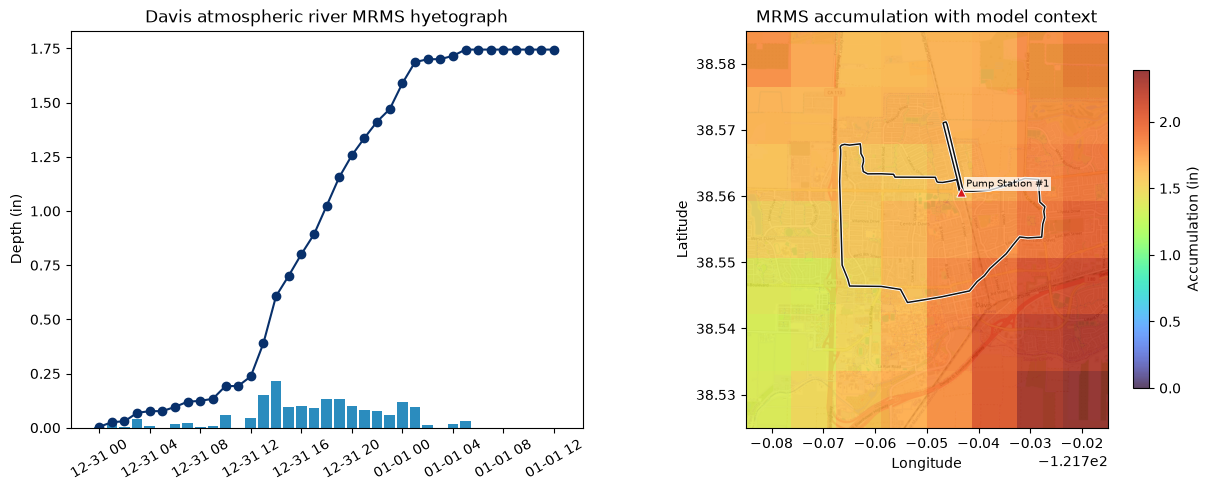

2026-07-11 06:38:32 - ras_commander.RasUnsteady - INFO - Updated Precipitation Hydrograph in DavisStormSystem.u01: 37 time steps, interval=1HOUR, total depth=0.0000 inches


2026-07-11 06:38:32 - ras_commander.RasCmdr - INFO - Applied 'balanced' HDF settings profile to plan: DavisStormSystem.p02


Updated precipitation boundary: area2
Simulation window: 2022-12-31 00:00:00 to 2023-01-01 18:00:00
Output Interval: 5MIN
Instantaneous Interval: 5MIN
Mapping Interval: 5MIN


2026-07-11 06:39:40 - ras_commander.RasUnsteady - INFO - Updated Precipitation Hydrograph in DavisStormSystem.u01: 37 time steps, interval=1HOUR, total depth=1.7300 inches


2026-07-11 06:39:40 - ras_commander.RasCmdr - INFO - Applied 'balanced' HDF settings profile to plan: DavisStormSystem.p02


...

,timestamp,raster,width,height,cell_size_ft,size_mb
0,2022-12-31 00:00:00,depth_20221231_000000.tif,682,569,28.845245,0.022989
1,2022-12-31 01:25:00,depth_20221231_012500.tif,682,569,28.845245,0.057809
2,2022-12-31 02:50:00,depth_20221231_025000.tif,682,569,28.845245,0.077873
27,2023-01-01 15:05:00,depth_20230101_150500.tif,682,569,28.845245,0.089363
28,2023-01-01 16:30:00,depth_20230101_163000.tif,682,569,28.845245,0.087853
29,2023-01-01 18:00:00,depth_20230101_180000.tif,682,569,28.845245,0.086547


Showing first and last 3 of 30 rows


,timestamp,wet_cells,wet_area_acres,max_depth_ft,mean_wet_depth_ft,hdf_max_depth_ft,wetness_matches_hdf
0,2022-12-31 00:00:00,0,0.000000,0.000000,0.000000,0.000000,True
1,2022-12-31 01:25:00,72459,1384.053652,0.502541,0.087701,0.162791,True
2,2022-12-31 02:50:00,9258,176.838884,2.418030,0.215997,0.329515,True
27,2023-01-01 15:05:00,11950,228.259307,3.542660,0.388752,2.006750,True
28,2023-01-01 16:30:00,11559,220.790739,3.529881,0.376261,2.001168,True
29,2023-01-01 18:00:00,11166,213.283969,3.530087,0.363610,2.001368,True


RAS Mapper stored maps with 2 HDF gap fill(s): 30 source timesteps, 30 terrain tiles consolidated to 30 single 28.845-ft rasters
Consolidated raster folder: G:\GH\ras-commander-wt-qpkit\working\CLB-642\examples_917_mrms_qpe_revisions\Davis_mrms_qpe_917_davis_ar\ConsolidatedDepthFrames_30_28.845ft\davis_atmospheric_river
Terrain tiles per source timestep: min=1, median=1, max=1


Video: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\CLB-642\examples_917_mrms_qpe_revisions\videos\mrms_precipitation_davis_atmospheric_river.mp4 (1,909,625 bytes)
Video: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\CLB-642\examples_917_mrms_qpe_revisions\videos\flood_inundation_depth_davis_atmospheric_river_5min.mp4 (760,285 bytes)
Video: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\CLB-642\examples_917_mrms_qpe_revisions\videos\combined_precip_flood_davis_atmospheric_river_5min.mp4 (1,084,085 bytes)


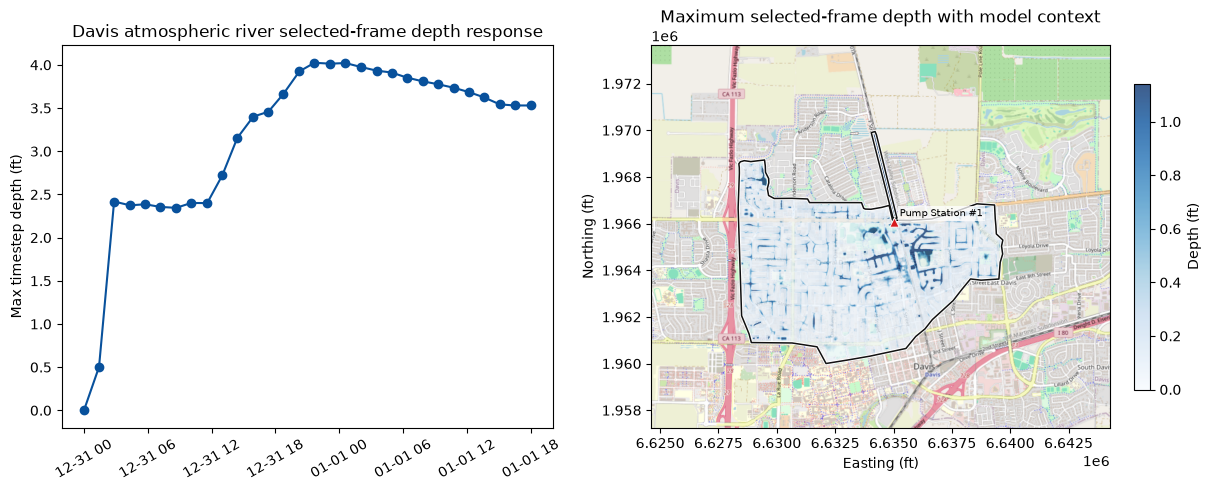

,mesh_name,reference_cell_id,selection_metric,peak_response_time,baseline_depth_ft,event_depth_ft,event_minus_baseline_depth_ft
0,area2,600,maximum concurrent event-minus-baseline depth,2022-12-31 21:30:00,0.0,2.568577,2.568577


,case,mesh_name,reference_cell_id,baseline_peak_depth_ft,event_peak_depth_ft,peak_depth_delta_ft,baseline_peak_wse_ft,event_peak_wse_ft,peak_wse_delta_ft,event_peak_precip_in_hr
0,davis_atmospheric_river,area2,600,0.0,2.568577,2.568577,37.542934,41.221306,3.678371,0.22


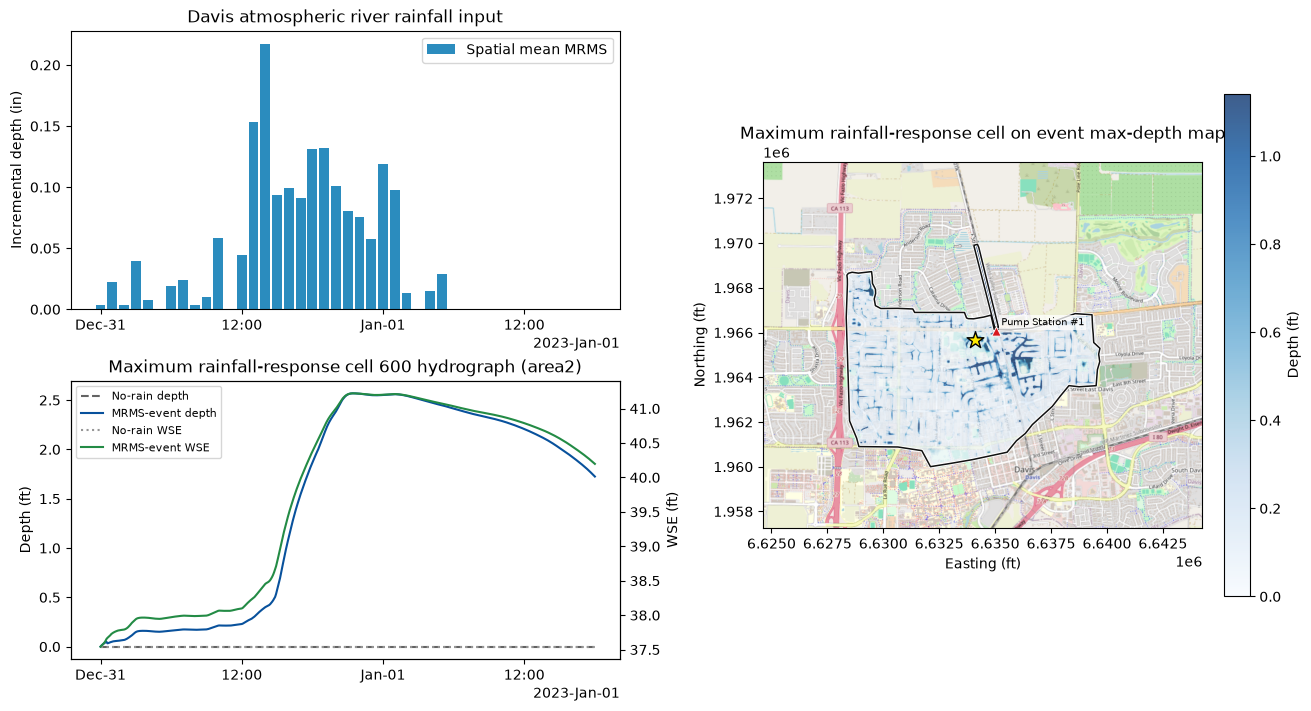

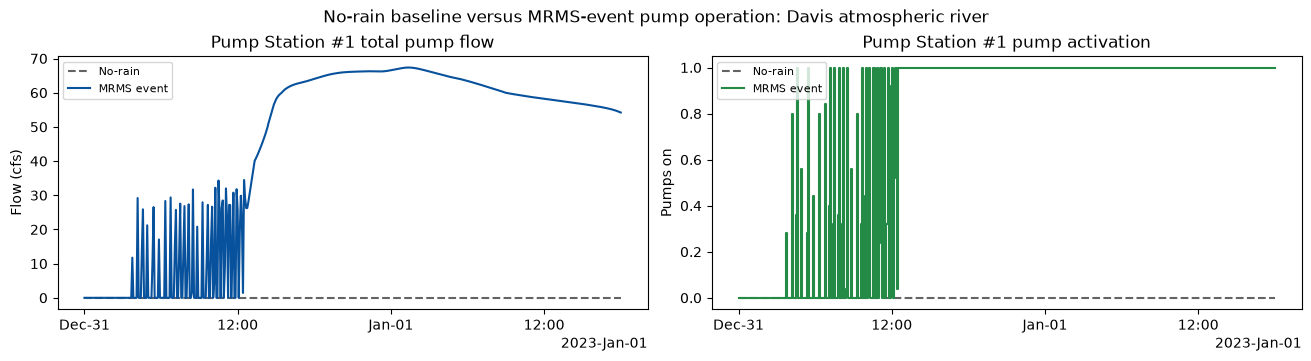

,station,baseline_peak_flow_cfs,event_peak_flow_cfs,peak_flow_delta_cfs,event_max_pumps_on,first_on,last_on
0,Pump Station #1,0.0,67.364868,67.364868,1.0,2022-12-31 03:45:00,2023-01-01 18:00:00


MP4 animations generated for Davis atmospheric river:


,animation,file,size_mb
0,Precipitation only,mrms_precipitation_davis_atmospheric_river.mp4,1.91
1,Flood inundation only,flood_inundation_depth_davis_atmospheric_river...,0.76
2,Combined precipitation and flood,combined_precip_flood_davis_atmospheric_river_...,1.08


In [4]:
results = []
results.append(run_mrms_case(CASES[0]))

2026-07-11 06:47:05 - ras_commander.RasExamples - INFO - Downloading special project 'NewOrleansMetro'...


NewOrleansMetro April 2024 flash flood
NWS New Orleans/Baton Rouge documented the 10 Apr 2024 New Orleans Metro severe thunderstorm and flash-flood event as a non-hurricane rainfall case.


2026-07-11 06:47:17 - ras_commander.RasExamples - INFO - Successfully extracted special project 'NewOrleansMetro' to NewOrleansMetro_mrms_qpe_917_nola_apr2024


Project folder: G:\GH\ras-commander-wt-qpkit\working\CLB-642\examples_917_mrms_qpe_revisions\NewOrleansMetro_mrms_qpe_917_nola_apr2024
Plan: 01; unsteady file: 01; geometry HDF: NewOrleansMetro.g02.hdf
Mesh areas: ['NewOrleans Metro']
HEC-RAS execution version: 7.0


,mesh_name,mesh_cells
0,NewOrleans Metro,20486


...

Showing first and last 3 of 24 rows


,pathname,start_time,end_time,rows,columns,minimum_mm,maximum_mm,mean_mm
0,/SHG/NOLA_APR10/PRECIPITATION/09APR2024:2300/0...,2024-04-09 23:00:00,2024-04-10 00:00:00,10,8,0.000000,0.000000,0.000000
1,/SHG/NOLA_APR10/PRECIPITATION/10APR2024:0000/1...,2024-04-10 00:00:00,2024-04-10 01:00:00,10,8,0.000000,0.000000,0.000000
2,/SHG/NOLA_APR10/PRECIPITATION/10APR2024:0100/1...,2024-04-10 01:00:00,2024-04-10 02:00:00,10,8,0.000000,0.000000,0.000000
21,/SHG/NOLA_APR10/PRECIPITATION/10APR2024:2000/1...,2024-04-10 20:00:00,2024-04-10 21:00:00,10,8,0.322925,1.066457,0.534419
22,/SHG/NOLA_APR10/PRECIPITATION/10APR2024:2100/1...,2024-04-10 21:00:00,2024-04-10 22:00:00,10,8,0.000000,0.000000,0.000000
23,/SHG/NOLA_APR10/PRECIPITATION/10APR2024:2200/1...,2024-04-10 22:00:00,2024-04-10 23:00:00,10,8,0.000000,0.000000,0.000000


Showing first and last 3 of 24 rows


,time,hour,incremental_depth,cumulative_depth
0,2024-04-10 00:00:00,1.0,0.000000,0.000000
1,2024-04-10 01:00:00,2.0,0.000000,0.000000
2,2024-04-10 02:00:00,3.0,0.000000,0.000000
21,2024-04-10 21:00:00,22.0,0.019166,4.095613
22,2024-04-10 22:00:00,23.0,0.000000,4.095613
23,2024-04-10 23:00:00,24.0,0.000000,4.095613


MRMS stack shape: (24, 14, 13)
Spatial-mean event depth: 4.096 inches
Serialized event depth: 4.100 inches (rounding difference=+0.0044 in)


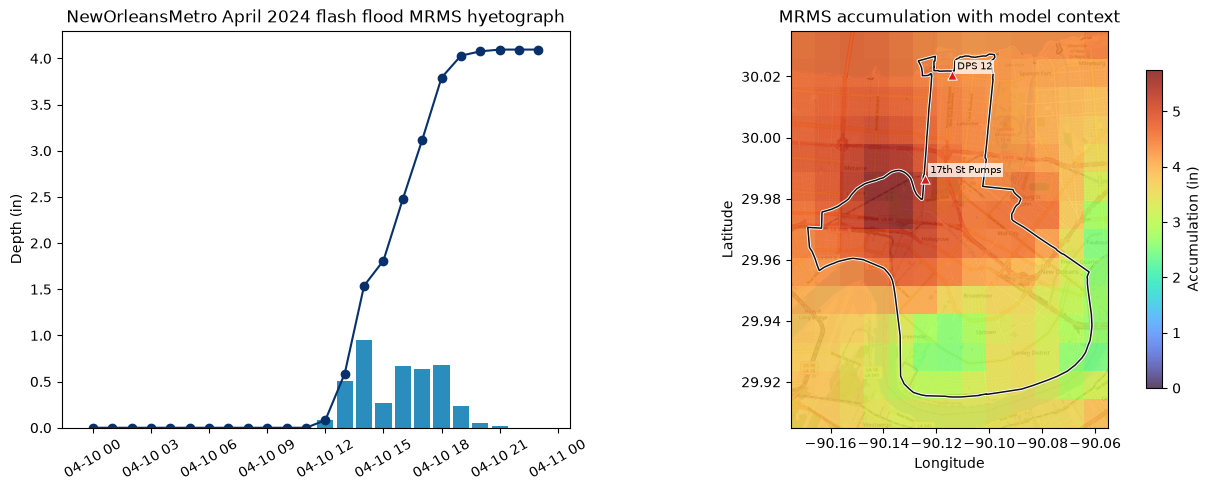

2026-07-11 06:48:05 - ras_commander.RasUnsteady - INFO - Updated Precipitation Hydrograph in NewOrleansMetro.u01: 24 time steps, interval=1HOUR, total depth=0.0000 inches


2026-07-11 06:48:05 - ras_commander.RasCmdr - INFO - Applied 'balanced' HDF settings profile to plan: NewOrleansMetro.p01


Updated precipitation boundary: NewOrleans Metro
Simulation window: 2024-04-10 00:00:00 to 2024-04-11 06:00:00
Output Interval: 5MIN
Instantaneous Interval: 5MIN
Mapping Interval: 5MIN


2026-07-11 06:59:57 - ras_commander.RasUnsteady - INFO - Updated Precipitation Hydrograph in NewOrleansMetro.u01: 24 time steps, interval=1HOUR, total depth=4.1000 inches


2026-07-11 06:59:57 - ras_commander.RasCmdr - INFO - Applied 'balanced' HDF settings profile to plan: NewOrleansMetro.p01


...

,timestamp,raster,width,height,cell_size_ft,size_mb
0,2024-04-10 00:00:00,depth_20240410_000000.tif,3611,4199,10.0,0.427427
1,2024-04-10 01:00:00,depth_20240410_010000.tif,3611,4199,10.0,0.429827
2,2024-04-10 02:00:00,depth_20240410_020000.tif,3611,4199,10.0,0.420459
27,2024-04-11 03:55:00,depth_20240411_035500.tif,3611,4199,10.0,6.872789
28,2024-04-11 04:55:00,depth_20240411_045500.tif,3611,4199,10.0,6.682877
29,2024-04-11 06:00:00,depth_20240411_060000.tif,3611,4199,10.0,6.495269


Showing first and last 3 of 30 rows


,timestamp,wet_cells,wet_area_acres,max_depth_ft,mean_wet_depth_ft,hdf_max_depth_ft,wetness_matches_hdf
0,2024-04-10 00:00:00,44879,103.028007,42.220322,10.144142,22.845560,True
1,2024-04-10 01:00:00,44862,102.988981,42.220219,10.147393,22.845457,True
2,2024-04-10 02:00:00,44842,102.943067,42.218864,10.151178,22.844105,True
27,2024-04-11 03:55:00,1643002,3771.813590,43.174515,1.075722,23.798901,True
28,2024-04-11 04:55:00,1580036,3627.263545,43.005337,1.081364,23.629763,True
29,2024-04-11 06:00:00,1518531,3486.067493,42.867332,1.084677,23.491747,True


RAS Mapper stored maps with 3 HDF gap fill(s): 30 source timesteps, 76 terrain tiles consolidated to 30 single 10.000-ft rasters
Consolidated raster folder: G:\GH\ras-commander-wt-qpkit\working\CLB-642\examples_917_mrms_qpe_revisions\NewOrleansMetro_mrms_qpe_917_nola_apr2024\ConsolidatedDepthFrames_30_10.000ft\neworleans_april2024_flash_flood
Terrain tiles per source timestep: min=1, median=3, max=3


Video: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\CLB-642\examples_917_mrms_qpe_revisions\videos\mrms_precipitation_neworleans_april2024_flash_flood.mp4 (1,456,776 bytes)
Video: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\CLB-642\examples_917_mrms_qpe_revisions\videos\flood_inundation_depth_neworleans_april2024_flash_flood_5min.mp4 (1,146,308 bytes)
Video: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\CLB-642\examples_917_mrms_qpe_revisions\videos\combined_precip_flood_neworleans_april2024_flash_flood_5min.mp4 (1,331,126 bytes)


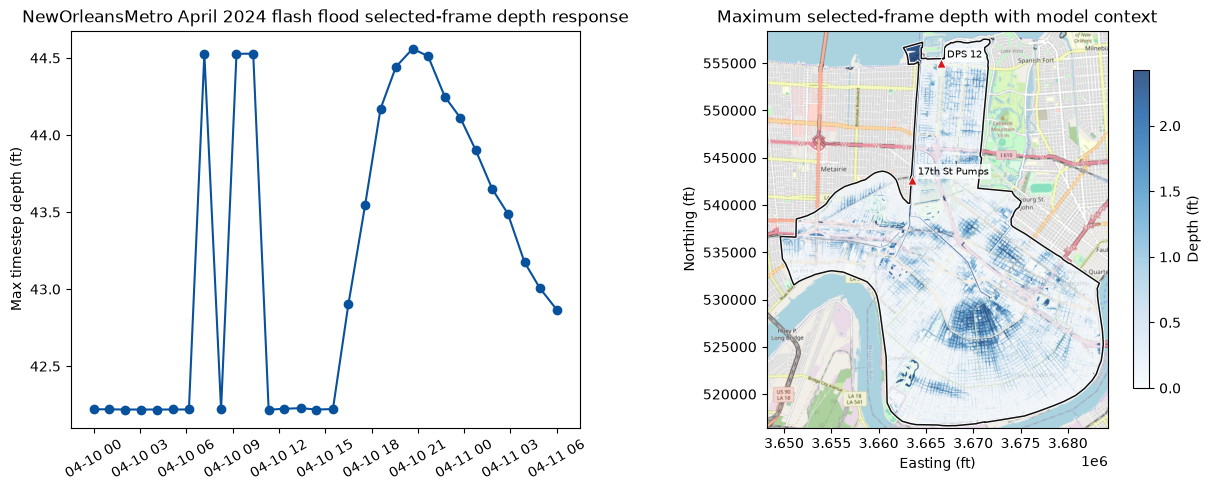

,mesh_name,reference_cell_id,selection_metric,peak_response_time,baseline_depth_ft,event_depth_ft,event_minus_baseline_depth_ft
0,NewOrleans Metro,17519,maximum concurrent event-minus-baseline depth,2024-04-10 15:40:00,0.0,19.675402,19.675402


,case,mesh_name,reference_cell_id,baseline_peak_depth_ft,event_peak_depth_ft,peak_depth_delta_ft,baseline_peak_wse_ft,event_peak_wse_ft,peak_wse_delta_ft,event_peak_precip_in_hr
0,neworleans_april2024_flash_flood,NewOrleans Metro,17519,0.0,19.675402,19.675402,-30.0,-9.534735,20.465265,0.95


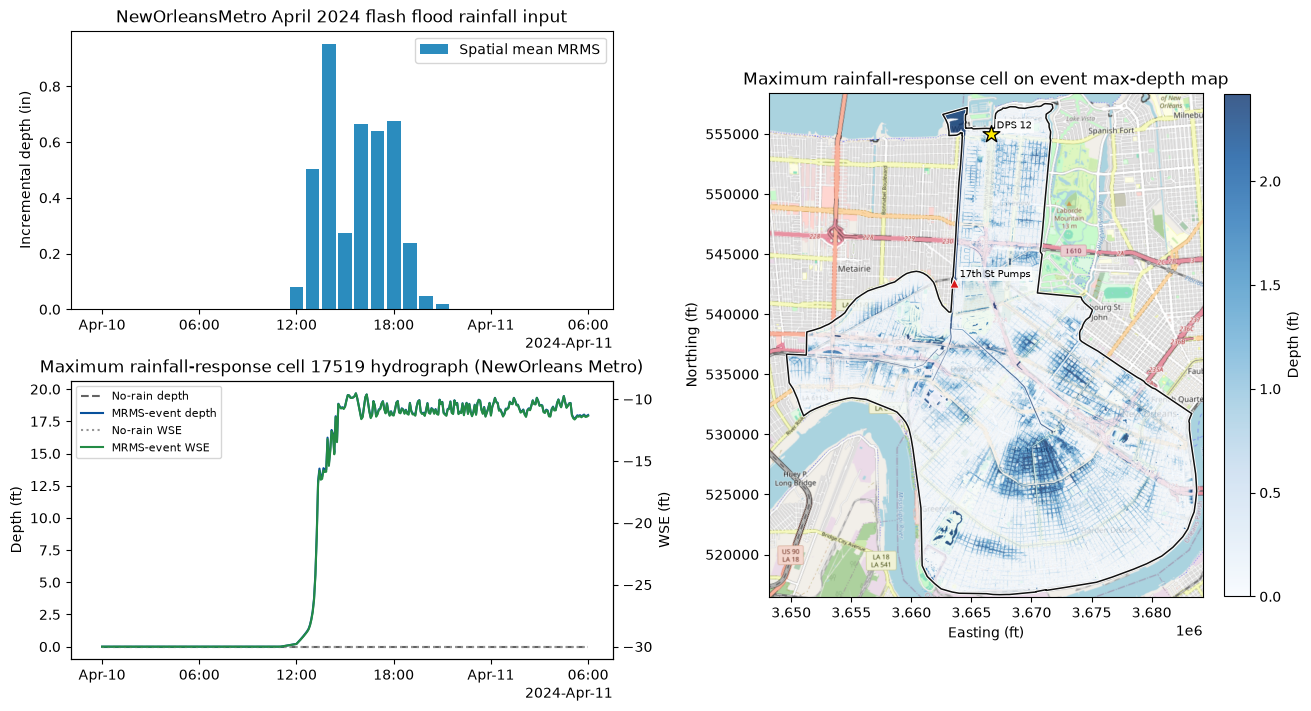

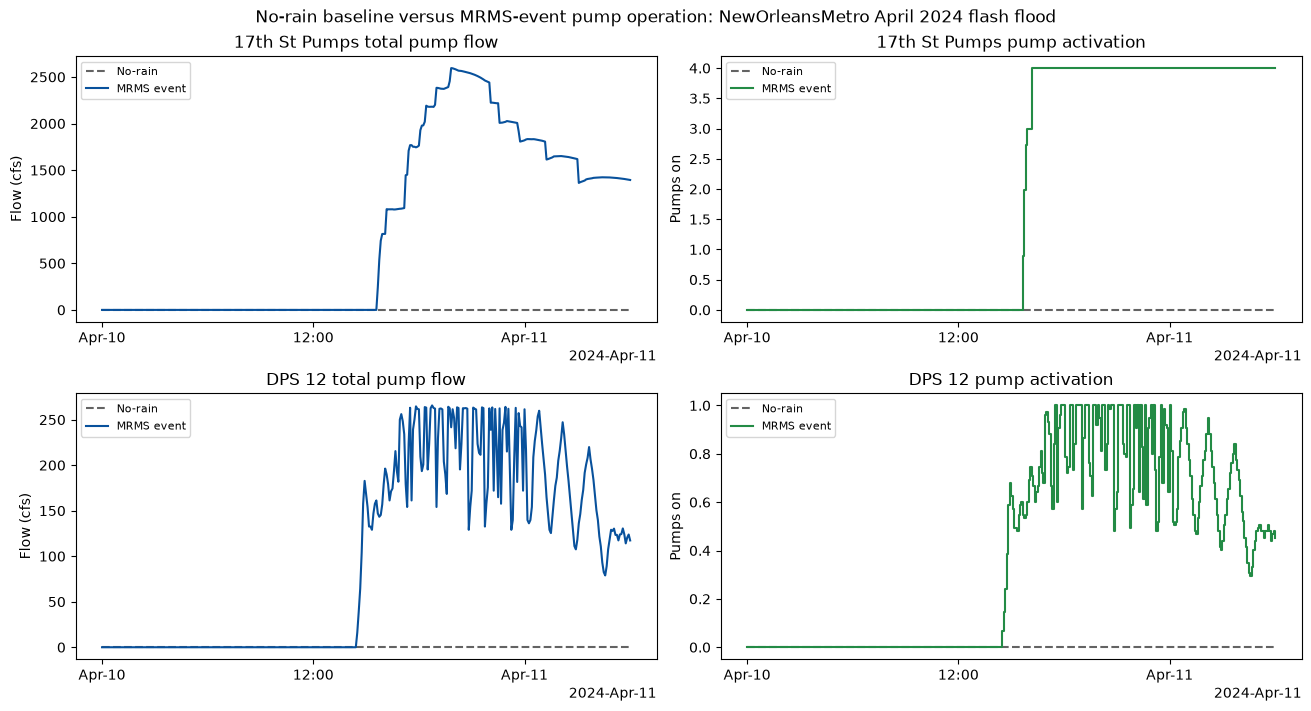

,station,baseline_peak_flow_cfs,event_peak_flow_cfs,peak_flow_delta_cfs,event_max_pumps_on,first_on,last_on
0,17th St Pumps,0.0,2594.963867,2594.963867,4.0,2024-04-10 15:40:00,2024-04-11 06:00:00
1,DPS 12,0.0,265.646820,265.646820,1.0,2024-04-10 14:30:00,2024-04-11 06:00:00


MP4 animations generated for NewOrleansMetro April 2024 flash flood:


,animation,file,size_mb
0,Precipitation only,mrms_precipitation_neworleans_april2024_flash_...,1.46
1,Flood inundation only,flood_inundation_depth_neworleans_april2024_fl...,1.15
2,Combined precipitation and flood,combined_precip_flood_neworleans_april2024_fla...,1.33


In [5]:
results.append(run_mrms_case(CASES[1]))

In [6]:
summary = pd.DataFrame(
    [
        {
            "case": result["case"],
            "mesh_count": result["mesh_count"],
            "pump_count": result["pump_count"],
            "pump_operation_stations": len(result["event_pump_operation"]),
            "reference_cell_id": result["reference_cell_id"],
            "peak_depth_delta_ft": result["reference_summary"].iloc[0]["peak_depth_delta_ft"],
            "peak_wse_delta_ft": result["reference_summary"].iloc[0]["peak_wse_delta_ft"],
            "total_output_timesteps": result["total_output_timesteps"],
            "available_animation_timesteps": result["available_animation_timesteps"],
            "animation_timesteps": result["animation_timesteps"],
            "animation_frames": result["animation_frames"],
            "depth_tile_count": result["depth_tile_count"],
            "consolidated_rasters": result["consolidated_raster_count"],
            "dominant_resolution_ft": result["dominant_terrain_resolution_ft"],
            "consolidated_resolution_ft": result["consolidation_cell_size_ft"],
            "hdf_gap_fills": result["hdf_gap_fill_count"],
            "dss_file": result["mrms_dss"].name,
            "videos": len(result["videos"]),
        }
        for result in results
    ]
)
display(summary)

,case,mesh_count,pump_count,pump_operation_stations,reference_cell_id,peak_depth_delta_ft,peak_wse_delta_ft,total_output_timesteps,available_animation_timesteps,animation_timesteps,animation_frames,depth_tile_count,consolidated_rasters,dominant_resolution_ft,consolidated_resolution_ft,hdf_gap_fills,dss_file,videos
0,davis_atmospheric_river,2,1,1,600,2.568577,3.678371,505,505,30,30,30,30,28.845245,28.845245,2,davis_atmospheric_river_mrms_qpe.dss,3
1,neworleans_april2024_flash_flood,1,2,2,17519,19.675402,20.465265,361,361,30,30,76,30,3.280000,10.000000,3,neworleans_april2024_flash_flood_mrms_qpe.dss,3


## Independent qpkit DSS Writer Verification

The main workflow above uses ras-commander's `PrecipMrms` acquisition and HEC-Vortex DSS conversion. This section independently writes the same Davis MRMS event with **qpkit v0.1.0**, verifies the complete catalog count, and reads the deterministic peak-hour spatial record through `RasDss.read_grid()`. It verifies an exact grid value and complete metadata without replacing the primary ras-commander workflow.

qpkit is an optional Apache-2.0 package by Gyan Basyal / WEST Consultants. Install the reviewed release in the terminal with `uv pip install "git+https://github.com/gyanz/qpkit.git@v0.1.0"`. The execution below deletes its prior DSS output first, requires a complete write with no failed records, and prints a concise summary instead of qpkit's per-file INFO stream.

In [7]:
import json
from datetime import timezone

try:
    import qpkit
    from pydsstools.core.crs import shg
    from qpkit import BoundingBox, QPERequest, QPKit
    from qpkit.models import QPEGridOptions
except ImportError as exc:
    raise ImportError(
        'This optional verification requires qpkit v0.1.0. Install it in the terminal with: '
        'uv pip install "git+https://github.com/gyanz/qpkit.git@v0.1.0"'
    ) from exc

assert qpkit.__version__.split('+', 1)[0] == "0.1.0", qpkit.__version__

davis = CASES[0]
qpkit_dir = RUN_ROOT / "qpkit_v010_davis_mrms"
qpkit_grib_dir = qpkit_dir / "grib2"
qpkit_grib_dir.mkdir(parents=True, exist_ok=True)
qpkit_dss = qpkit_dir / "davis_mrms_qpe_v010.dss"
qpkit_dss.unlink(missing_ok=True)

request = QPERequest(
    product="MultiSensor_Pass2",
    interval=1,
    start=davis["event_start"].replace(tzinfo=timezone.utc),
    end=davis["event_last_qpe"].replace(tzinfo=timezone.utc),
    source="aws",
)
options = QPEGridOptions(
    part_a="MRMS",
    part_b=davis["dss_b"],
    part_c="PRECIP",
    part_f=f"{davis['dss_f']}_QPKIT",
    crs=shg(),
    cell_size=None,
    extents=BoundingBox(
        left_lon=DAVIS_BOUNDS[0],
        bottom_lat=DAVIS_BOUNDS[1],
        right_lon=DAVIS_BOUNDS[2],
        top_lat=DAVIS_BOUNDS[3],
    ),
)

qpkit_logger = logging.getLogger("qpkit")
previous_qpkit_level = qpkit_logger.level
qpkit_logger.setLevel(logging.WARNING)
try:
    with QPKit() as kit:
        qpkit_result = kit.download_to_dss(
            request,
            qpkit_grib_dir,
            qpkit_dss,
            grid_options=options,
            dss_version=6,
        )
finally:
    qpkit_logger.setLevel(previous_qpkit_level)

expected_qpkit_records = int(
    (davis["event_last_qpe"] - davis["event_start"]).total_seconds() // 3600
) + 1
assert not qpkit_result.download.failed, qpkit_result.download.failed
assert not qpkit_result.dss.failed, qpkit_result.dss.failed
assert len(qpkit_result.dss.written) == expected_qpkit_records
assert qpkit_dss.exists() and qpkit_dss.stat().st_size > 0

qpkit_catalog = RasDss.get_catalog(qpkit_dss)
assert len(qpkit_catalog) == expected_qpkit_records

davis_peak_end = results[0]["dss_grid_audit"].loc[
    results[0]["dss_grid_audit"]["mean_mm"].idxmax(), "end_time"
]
peak_end_part = pd.Timestamp(davis_peak_end).strftime("%d%b%Y:%H%M").upper()
matching_pathnames = [
    pathname
    for pathname in qpkit_catalog["pathname"].astype(str)
    if pathname.split("/")[5].upper() == peak_end_part
]
assert len(matching_pathnames) == 1, matching_pathnames

qpkit_grid = RasDss.read_grid(qpkit_dss, matching_pathnames[0])
qpkit_values = np.asarray(qpkit_grid["data"], dtype=float)
assert np.isfinite(qpkit_values).any()
qpkit_row, qpkit_col = np.unravel_index(np.nanargmax(qpkit_values), qpkit_values.shape)
qpkit_value = float(qpkit_values[qpkit_row, qpkit_col])
qpkit_metadata = qpkit_grid["metadata"]
assert qpkit_value > 0
assert qpkit_grid["units"].upper() == "MM"
assert qpkit_grid["data_type"].upper() == "PER-CUM"
assert qpkit_grid["grid_type"] == "albers"

print(f"Verified exact qpkit pathname: {matching_pathnames[0]}")
qpkit_readback = {
    "pathname": matching_pathnames[0],
    "indexed_value": {
        "row": int(qpkit_row),
        "column": int(qpkit_col),
        "value_mm": qpkit_value,
    },
    "units": qpkit_grid["units"],
    "data_type": qpkit_grid["data_type"],
    "grid_type": qpkit_grid["grid_type"],
    "crs": qpkit_grid["crs"],
    "cell_size": qpkit_grid["cell_size"],
    "shape": qpkit_grid["shape"],
    "origin": qpkit_metadata["origin"],
    "lower_left_cell": qpkit_metadata["lower_left_cell"],
    "missing_values": qpkit_metadata["number_missing"],
    "nodata_value": qpkit_metadata["nodata_value"],
}
print("Verified qpkit grid metadata (non-truncated):")
print(json.dumps(qpkit_readback, indent=2))
display(
    pd.DataFrame(
        [
            {
                "row": int(qpkit_row),
                "column": int(qpkit_col),
                "value_mm": qpkit_value,
                "units": qpkit_grid["units"],
                "data_type": qpkit_grid["data_type"],
                "grid_type": qpkit_grid["grid_type"],
                "crs": qpkit_grid["crs"],
                "cell_size": qpkit_grid["cell_size"],
                "shape": qpkit_grid["shape"],
                "origin": qpkit_metadata["origin"],
                "lower_left_cell": qpkit_metadata["lower_left_cell"],
                "missing_values": qpkit_metadata["number_missing"],
                "nodata_value": qpkit_metadata["nodata_value"],
            }
        ]
    )
)
print(
    f"qpkit {qpkit.__version__}: "
    f"downloaded={len(qpkit_result.download.succeeded)}, "
    f"cached={len(qpkit_result.download.skipped)}, "
    f"DSS grids written={len(qpkit_result.dss.written)}, "
    f"catalog records={len(qpkit_catalog)}"
)
print(f"Fresh DSS output: {qpkit_dss}")
if qpkit_result.download.skipped:
    print("qpkit reused cached source grids; the DSS file above was deleted and recreated in this run.")
display_preview(qpkit_catalog)

Verified exact qpkit pathname: /MRMS/DAVIS_AR/PRECIP/31DEC2022:1300/31DEC2022:1400/MRMS_AR_20221231_QPKIT/
Verified qpkit grid metadata (non-truncated):
{
  "pathname": "/MRMS/DAVIS_AR/PRECIP/31DEC2022:1300/31DEC2022:1400/MRMS_AR_20221231_QPKIT/",
  "indexed_value": {
    "row": 3,
    "column": 5,
    "value_mm": 6.900000095367432
  },
  "units": "mm",
  "data_type": "PER-CUM",
  "grid_type": "albers",
  "crs": "PROJCS[\"USA_Contiguous_Albers_Equal_Area_Conic_USGS_version\",GEOGCS[\"GCS_North_American_1983\",DATUM[\"D_North_American_1983\",SPHEROID[\"GRS_1980\",6378137.0,298.257222101]],PRIMEM[\"Greenwich\",0.0],UNIT[\"Degree\",0.0174532925199433]],PROJECTION[\"Albers\"],PARAMETER[\"False_Easting\",0.0],PARAMETER[\"False_Northing\",0.0],PARAMETER[\"Central_Meridian\",-96.0],PARAMETER[\"Standard_Parallel_1\",29.5],PARAMETER[\"Standard_Parallel_2\",45.5],PARAMETER[\"Latitude_Of_Origin\",23.0],UNIT[\"Meter\",1.0]]",
  "cell_size": 985.2755126953125,
  "shape": [
    11,
    10
  ],
  "or

,row,column,value_mm,units,data_type,grid_type,crs,cell_size,shape,origin,lower_left_cell,missing_values,nodata_value
0,3,5,6.9,mm,PER-CUM,albers,"PROJCS[""USA_Contiguous_Albers_Equal_Area_Conic...",985.275513,"(11, 10)","(-2201105.495361328, 2018829.5255126953)","(-2234, 2049)",37,-3.402823e+38


qpkit 0.1.0: downloaded=0, cached=37, DSS grids written=37, catalog records=37
Fresh DSS output: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\CLB-642\examples_917_mrms_qpe_revisions\qpkit_v010_davis_mrms\davis_mrms_qpe_v010.dss
qpkit reused cached source grids; the DSS file above was deleted and recreated in this run.
Showing first and last 3 of 37 rows


,pathname
0,/MRMS/DAVIS_AR/PRECIP/30DEC2022:2300/30DEC2022...
1,/MRMS/DAVIS_AR/PRECIP/31DEC2022:0000/31DEC2022...
2,/MRMS/DAVIS_AR/PRECIP/31DEC2022:0100/31DEC2022...
34,/MRMS/DAVIS_AR/PRECIP/01JAN2023:0900/01JAN2023...
35,/MRMS/DAVIS_AR/PRECIP/01JAN2023:1000/01JAN2023...
36,/MRMS/DAVIS_AR/PRECIP/01JAN2023:1100/01JAN2023...


## Reviewer Artifact Summary


In [8]:
print("Final reviewer artifacts generated by this notebook run:")
for result in results:
    print(f"- {result['case']}")
    print(f"  Project folder: {result['project_folder']}")
    print(f"  Plan HDF: {result['plan_hdf']} ({result['plan_hdf'].stat().st_size:,} bytes)")
    print(
        f"  No-rain baseline HDF: {result['baseline_plan_hdf']} "
        f"({result['baseline_plan_hdf'].stat().st_size:,} bytes)"
    )
    print(f"  MRMS DSS: {result['mrms_dss']} ({result['mrms_dss'].stat().st_size:,} bytes)")
    print(
        f"  Source tile frames: {len(result['depth_tile_frames'])}; "
        f"terrain tiles: {result['depth_tile_count']}; "
        f"consolidated rasters: {result['consolidated_raster_count']}; "
        f"cell size: {result['consolidation_cell_size_ft']:.3f} ft; "
        f"HDF gap fills: {result['hdf_gap_fill_count']}"
    )
    print(f"  Consolidated raster folder: {result['consolidated_depth_rasters'][0].parent}")
    print(f"  Reference cell: {result['reference_cell_id']}")
    print(f"  Pump operation stations plotted: {len(result['event_pump_operation'])}")
    for video in result["videos"]:
        print(f"  Video artifact: {video} ({video.stat().st_size:,} bytes)")

print(f"- qpkit MRMS DSS: {qpkit_dss} ({qpkit_dss.stat().st_size:,} bytes)")
print(f"  qpkit catalog records: {len(qpkit_catalog)}")

Final reviewer artifacts generated by this notebook run:
- davis_atmospheric_river
  Project folder: G:\GH\ras-commander-wt-qpkit\working\CLB-642\examples_917_mrms_qpe_revisions\Davis_mrms_qpe_917_davis_ar
  Plan HDF: G:\GH\ras-commander-wt-qpkit\working\CLB-642\examples_917_mrms_qpe_revisions\Davis_mrms_qpe_917_davis_ar\DavisStormSystem.p02.hdf (50,485,102 bytes)
  No-rain baseline HDF: G:\GH\ras-commander-wt-qpkit\working\CLB-642\examples_917_mrms_qpe_revisions\Davis_mrms_qpe_917_davis_ar\Precipitation\davis_atmospheric_river\davis_atmospheric_river_no_rain_baseline.p02.hdf (3,595,461 bytes)
  MRMS DSS: G:\GH\ras-commander-wt-qpkit\working\CLB-642\examples_917_mrms_qpe_revisions\Davis_mrms_qpe_917_davis_ar\Precipitation\davis_atmospheric_river\davis_atmospheric_river_mrms_qpe.dss (220,608 bytes)
  Source tile frames: 30; terrain tiles: 30; consolidated rasters: 30; cell size: 28.845 ft; HDF gap fills: 2
  Consolidated raster folder: G:\GH\ras-commander-wt-qpkit\working\CLB-642\exampl